In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import rasterio
import joblib
from rasterio import plot
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import math
from skimage.measure import block_reduce
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.interpolate import griddata

In [7]:
from utils.site import Site
from utils.tree import Tree
from utils.ethz_map import ETHZMap
from utils.constants import SILVER_FOLDERPATH, ETHZ_COCOA_GH_MAP_UINT8_FILEPATH

In [8]:
ethz_map = ETHZMap.from_tif(ETHZ_COCOA_GH_MAP_UINT8_FILEPATH)

2026-06-03 14:38:02.388 | INFO     | utils.ethz_map:from_tif:24 - Loading /home/aga/Documents/clients/forestero/skymap/skymap/data/silver/cocoa_gh_map_uint8.tif...
2026-06-03 14:38:02.391 | INFO     | utils.ethz_map:from_tif:26 - Boundaries of the map
2026-06-03 14:38:02.392 | INFO     | utils.ethz_map:from_tif:27 - Lon: -3.26° --> 1.19°
2026-06-03 14:38:02.392 | INFO     | utils.ethz_map:from_tif:28 - Lat: 4.54° --> 11.17°
100%|███████████████████████████████████████████████████████████████████████████████████████| 73264/73264 [00:07<00:00, 9837.71it/s]
2026-06-03 14:38:10.001 | INFO     | utils.ethz_map:from_tif:42 - Memory used by array: 3.36 GB


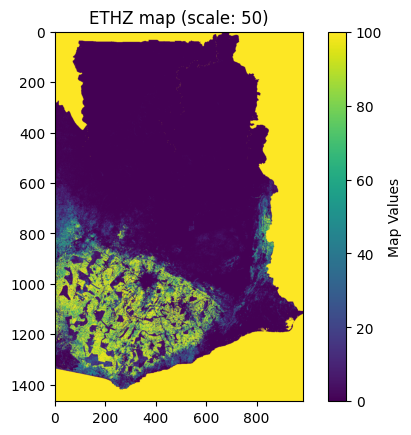

In [28]:
ethz_map.plot(scale_factor=50)

In [37]:
# Look at each site's ETHZ map
sites = joblib.load(SILVER_FOLDERPATH / "sites.pkl")

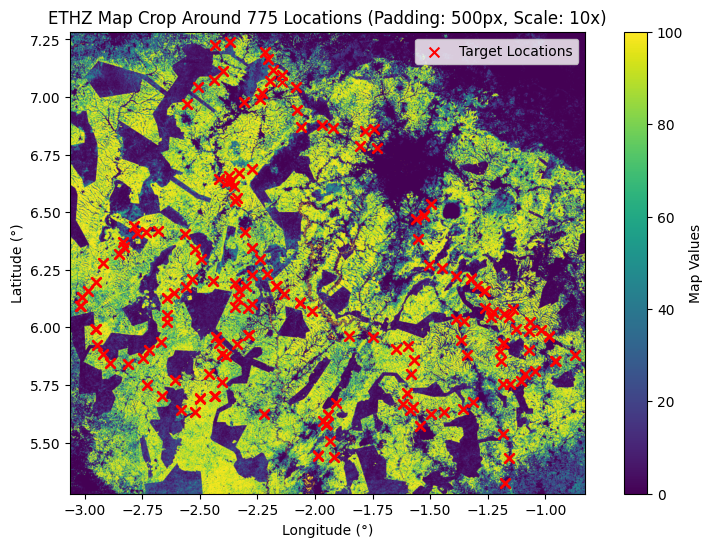

In [56]:
lat_lons = []
for s in sites:
    lat_lons += s.lat_lons
    
ethz_map.plot_around_lat_lons(lat_lons, padding_px=500, scale_factor=10)

AC01


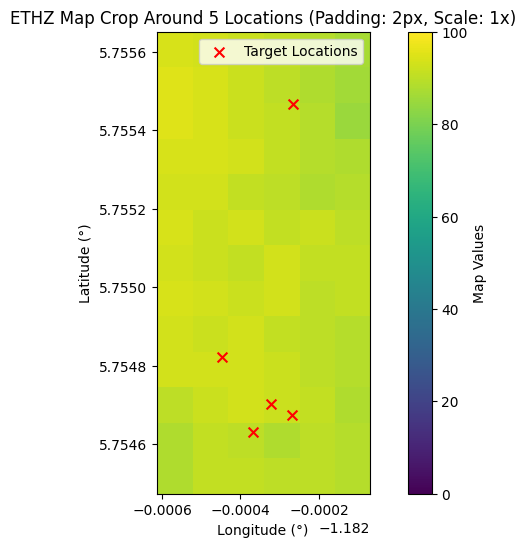

AC02


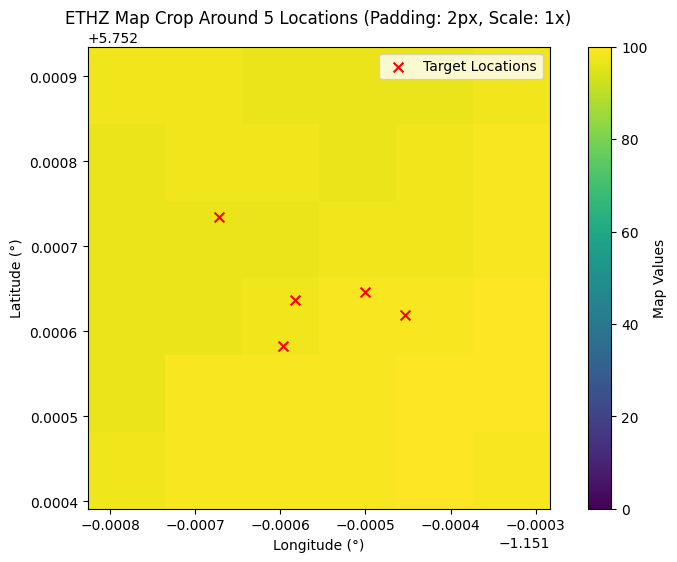

AC03


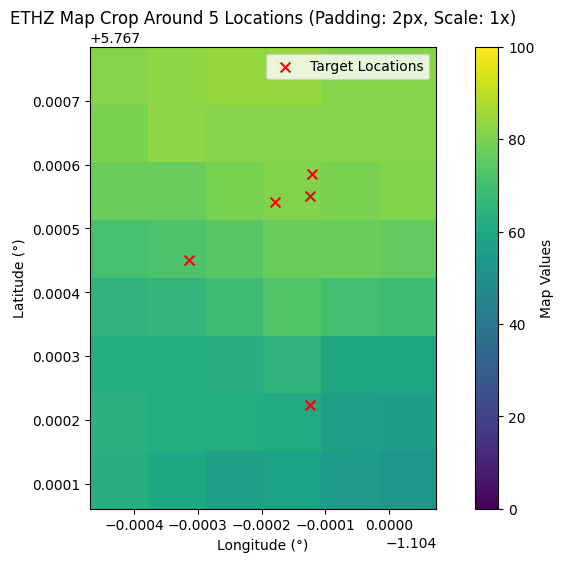

AC04


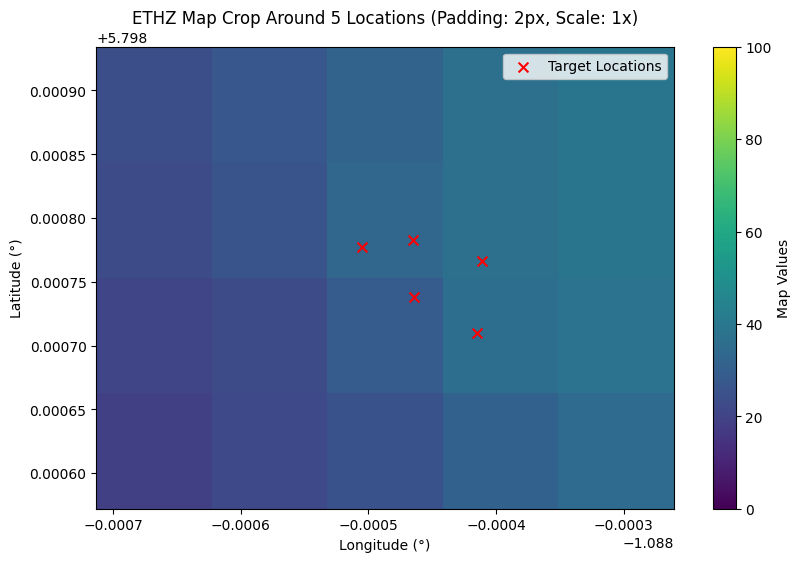

AC05


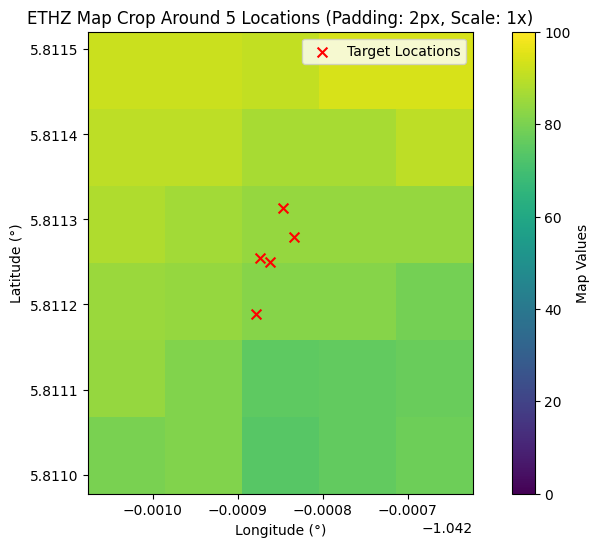

AC06


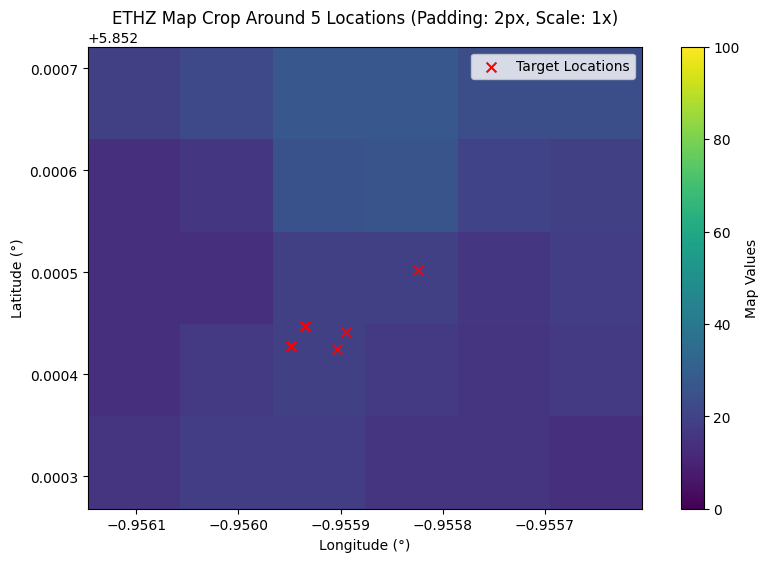

AC07


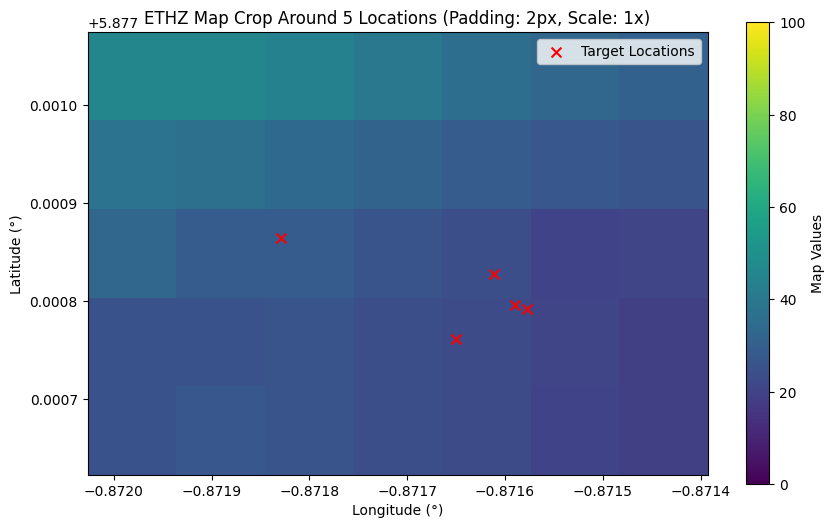

AK01


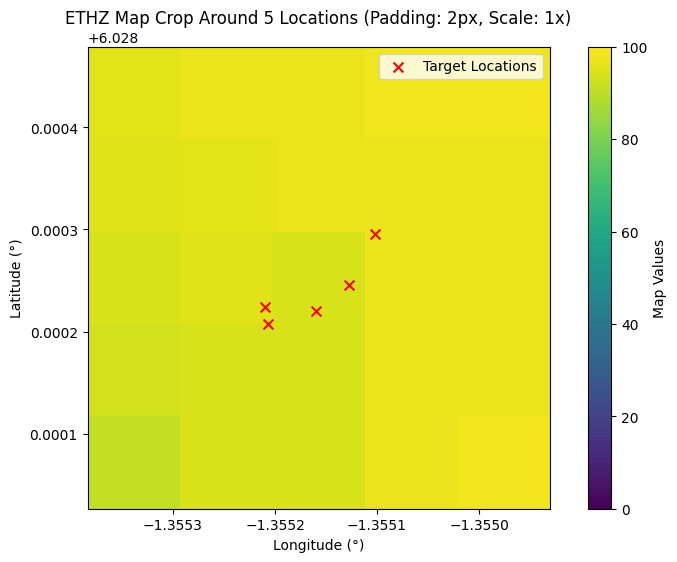

AK02


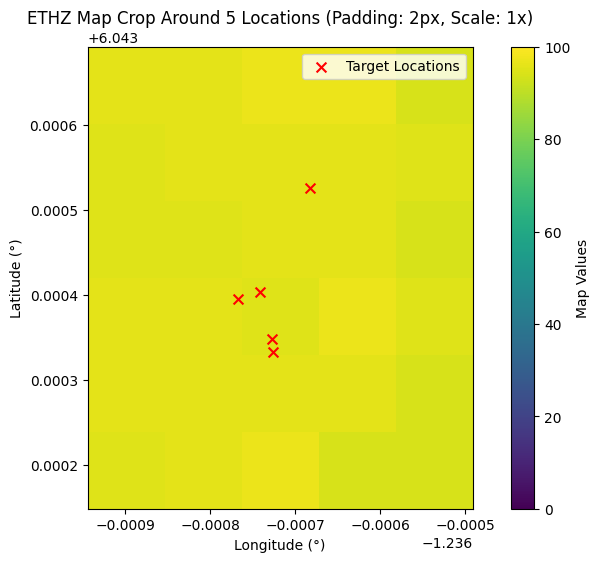

AK03


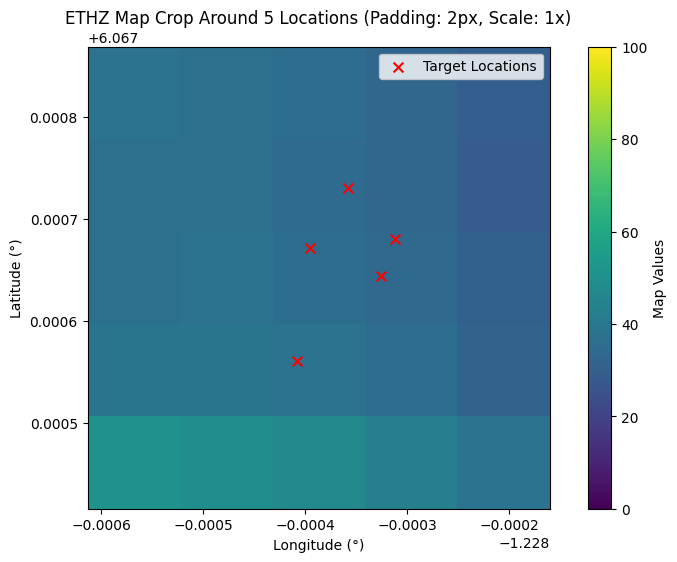

AK04


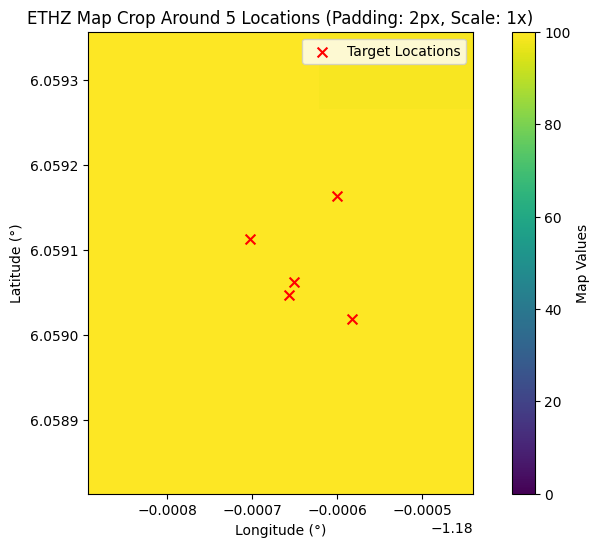

AK05


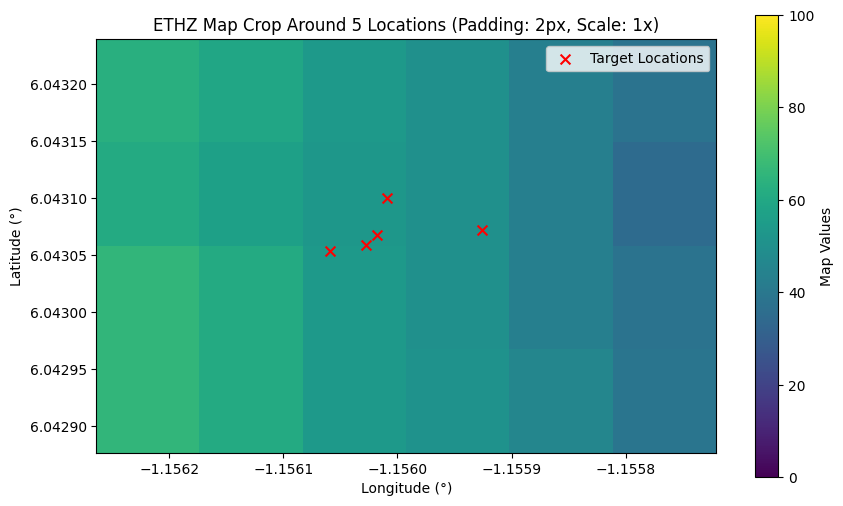

AK06


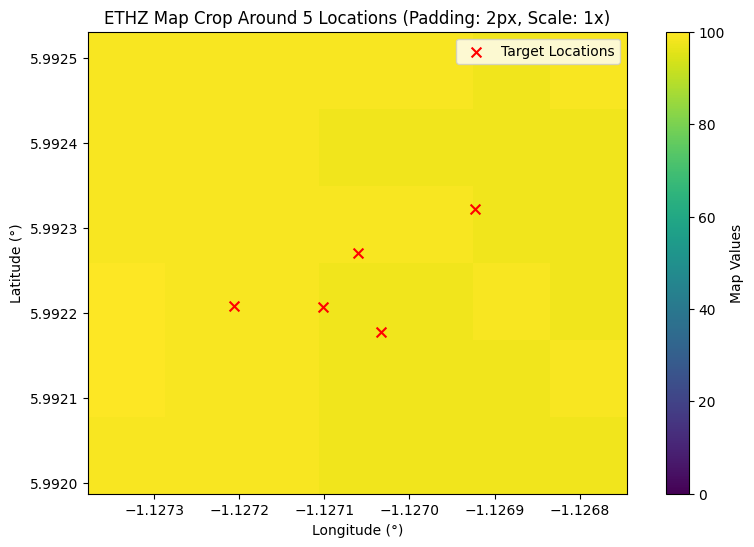

AK07


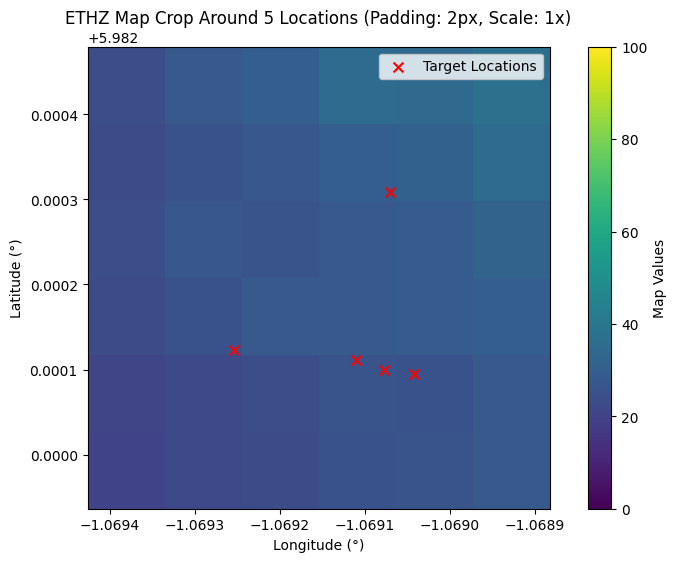

AK08


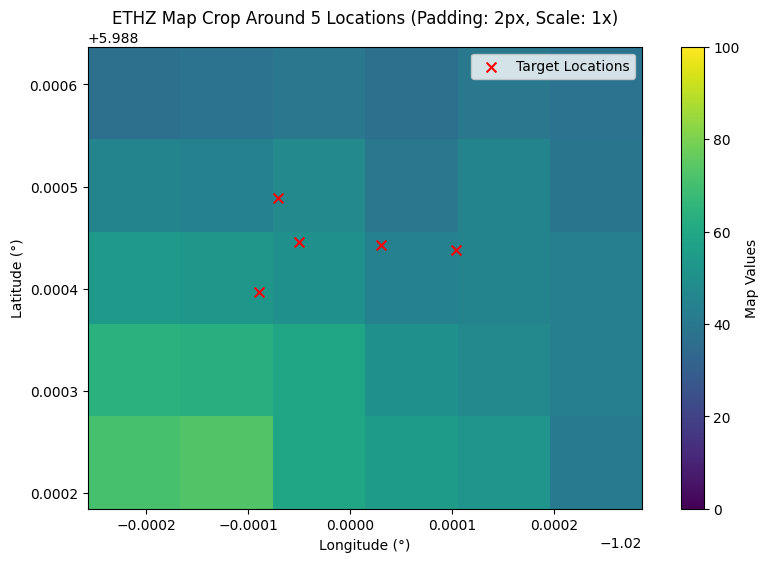

AK10


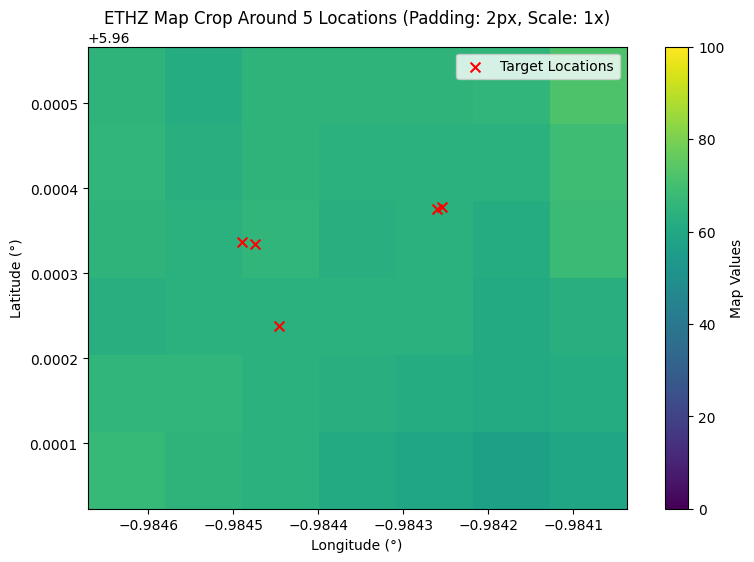

AK11


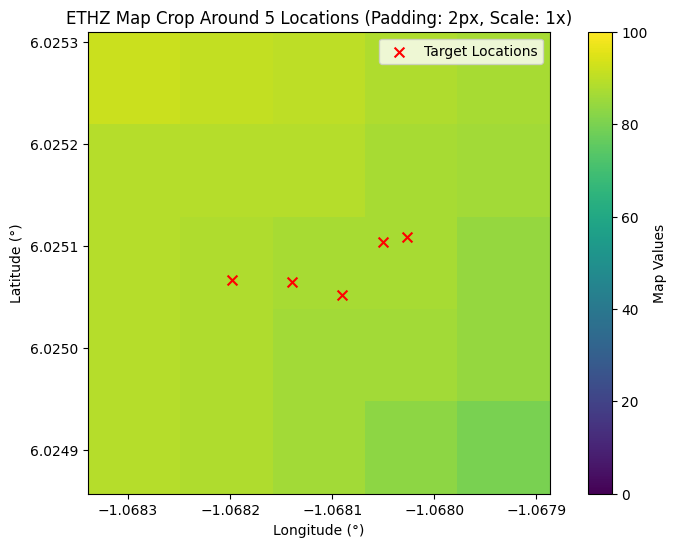

AK12


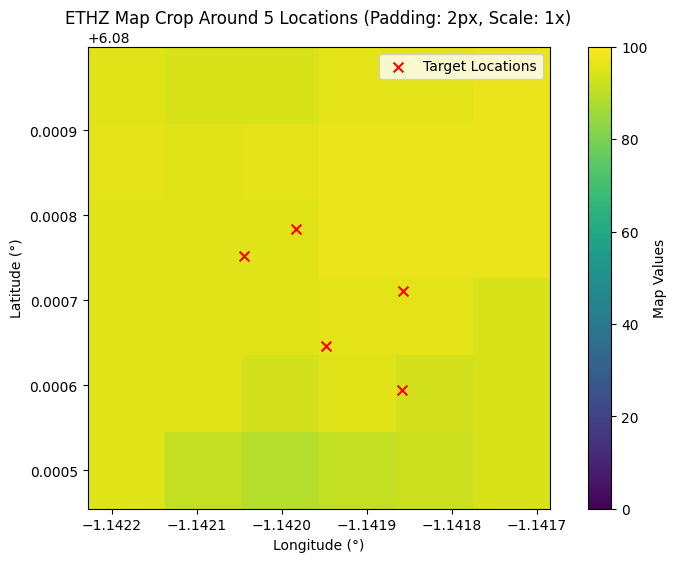

BC01


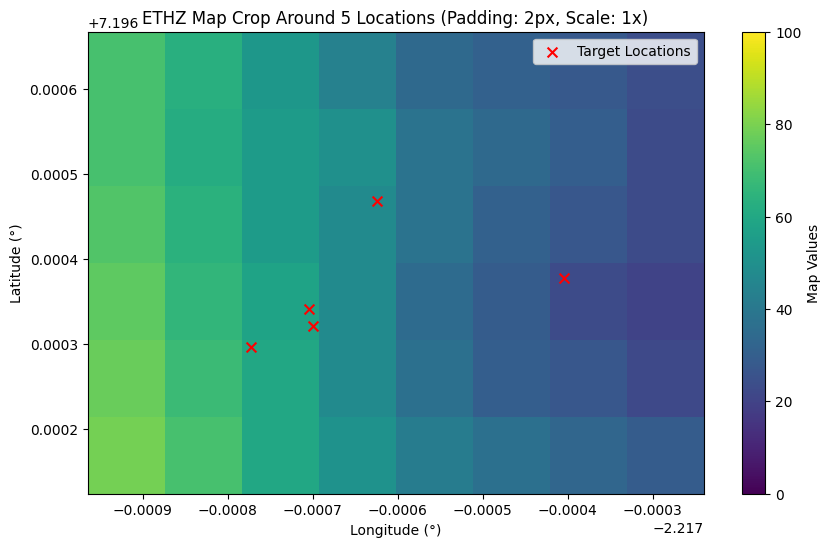

BC02


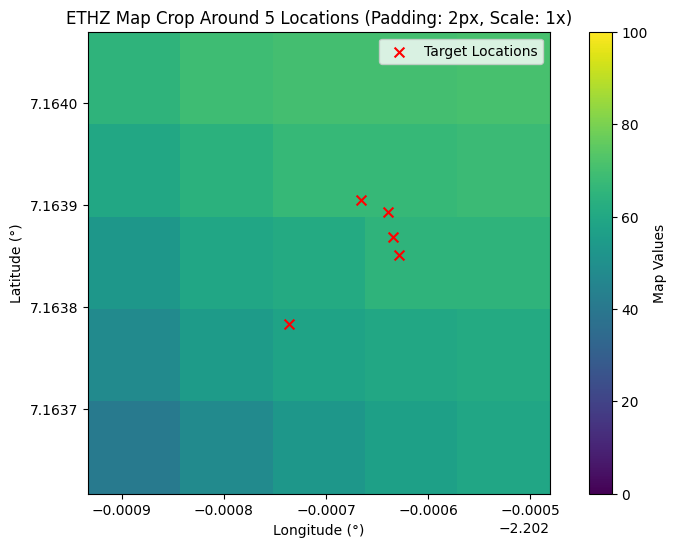

BC03


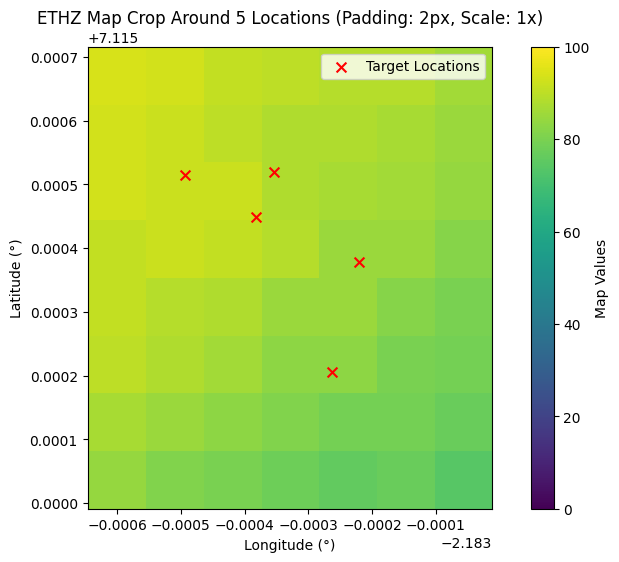

BI01


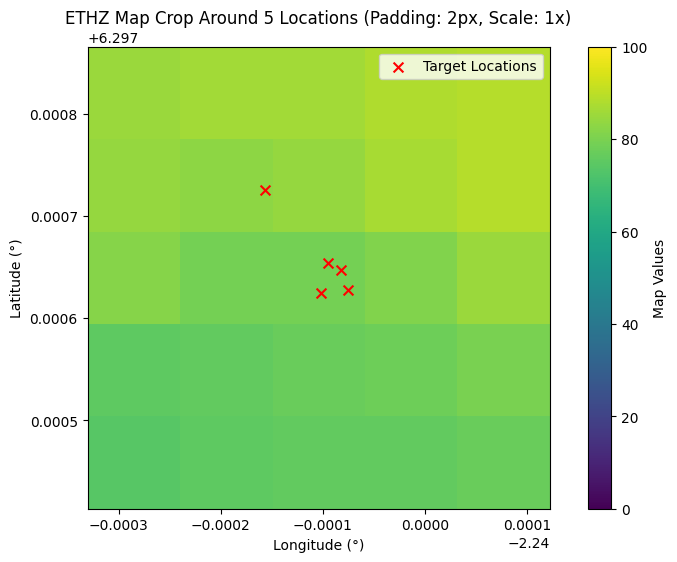

BI02


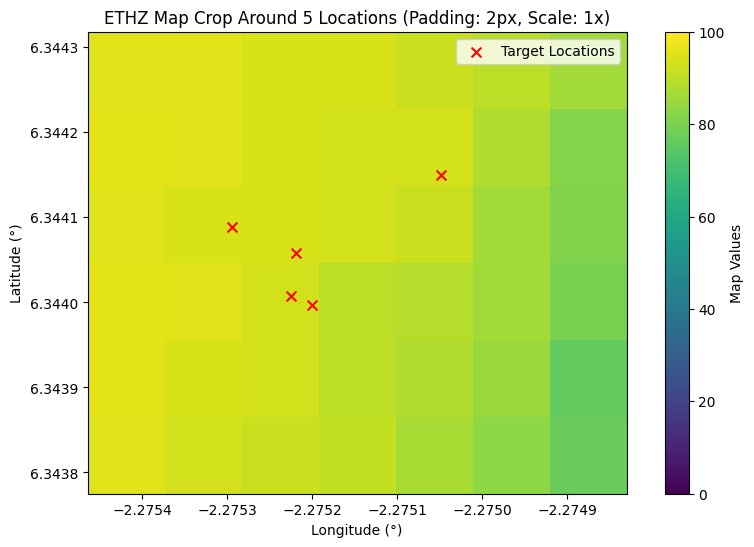

BI03


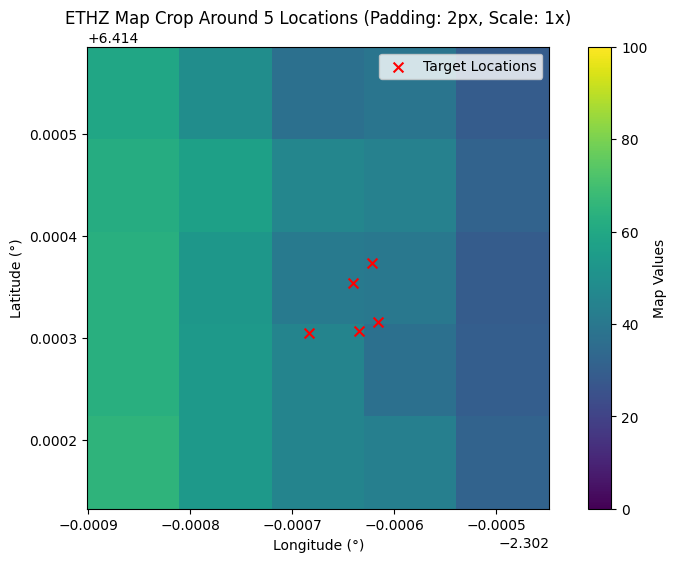

BI04


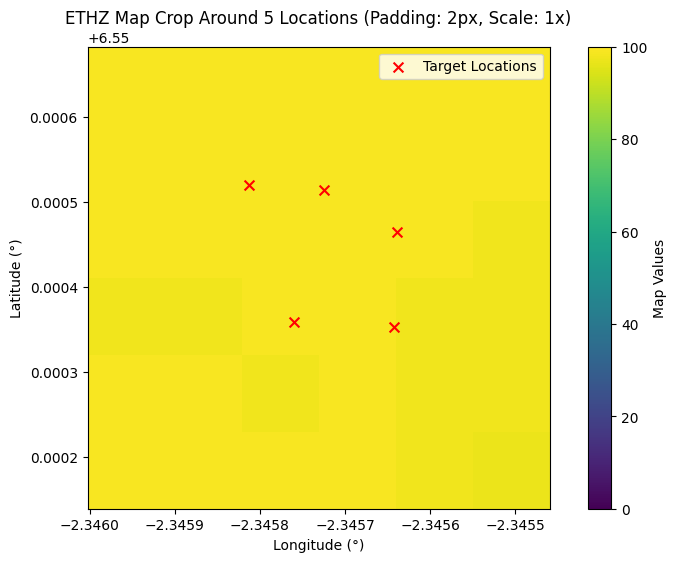

BI05


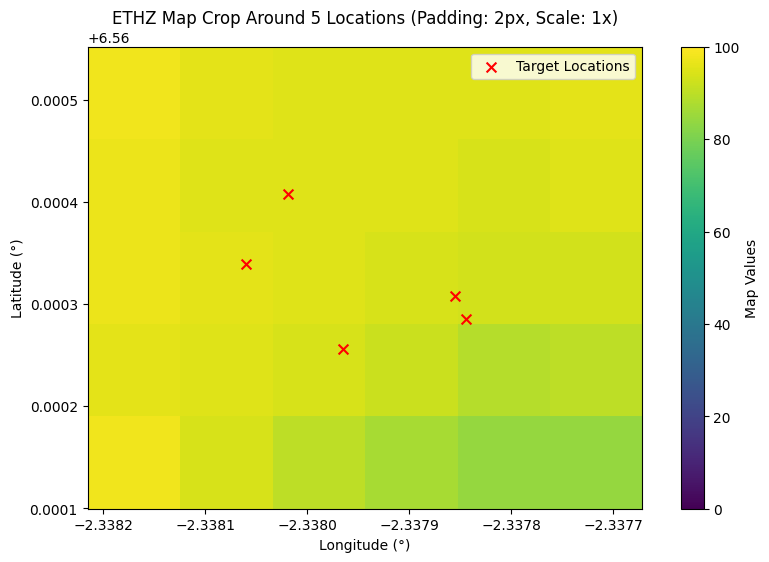

BI06


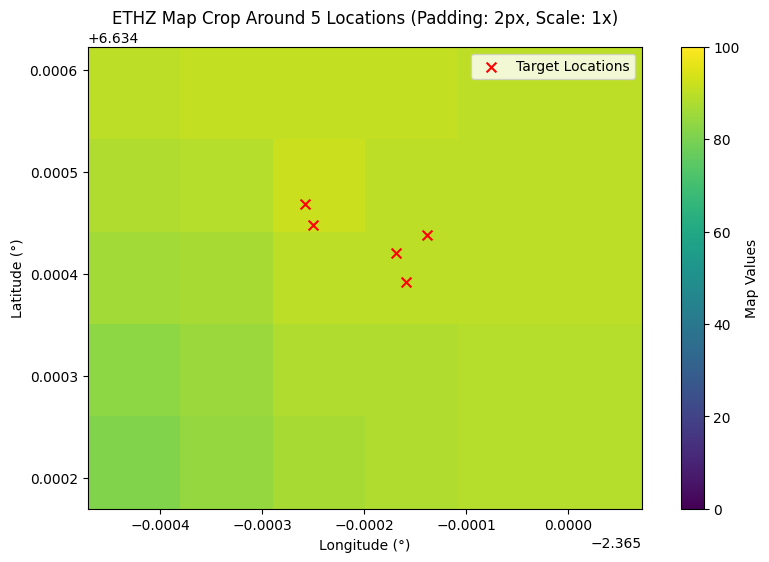

BI07


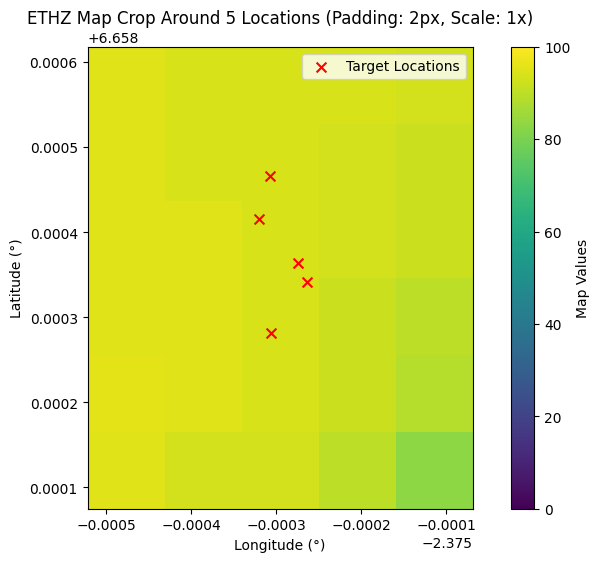

BI08


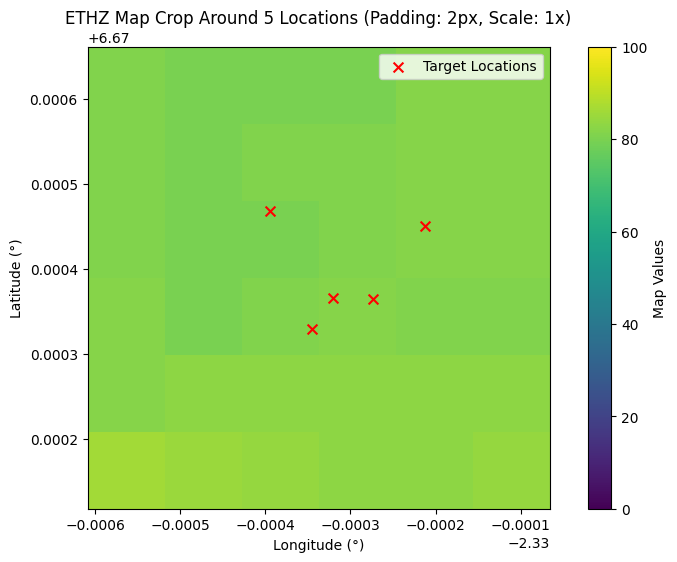

BI09


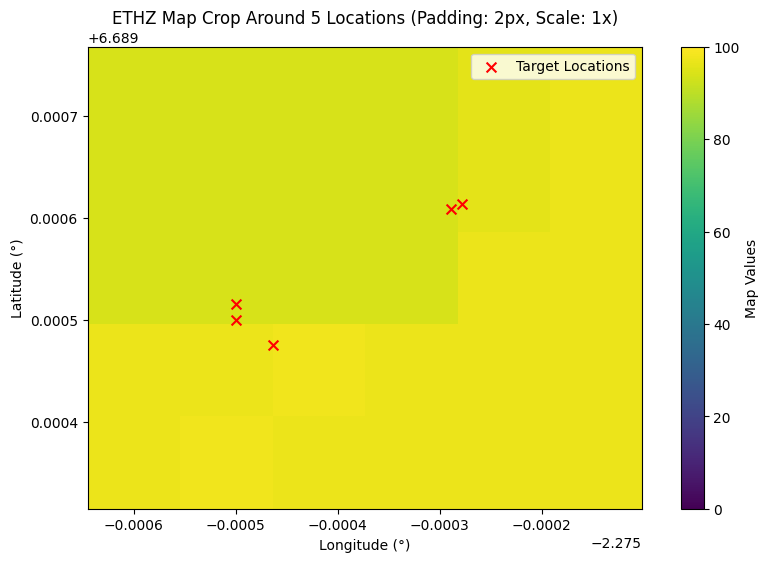

BI10


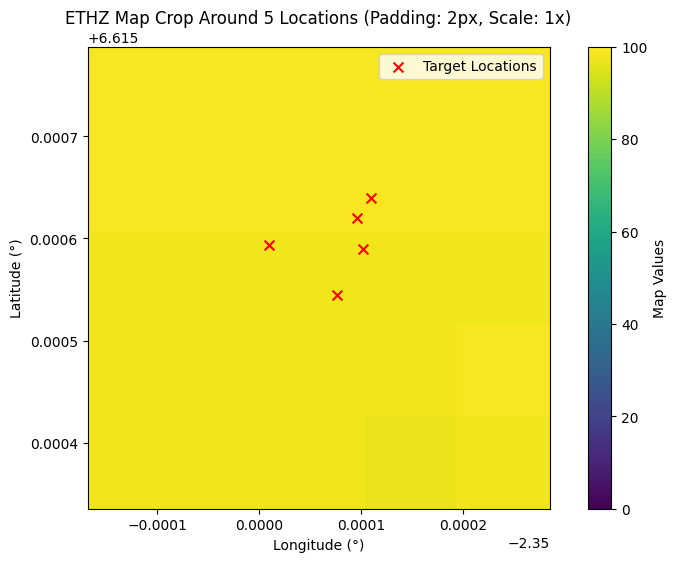

BI11


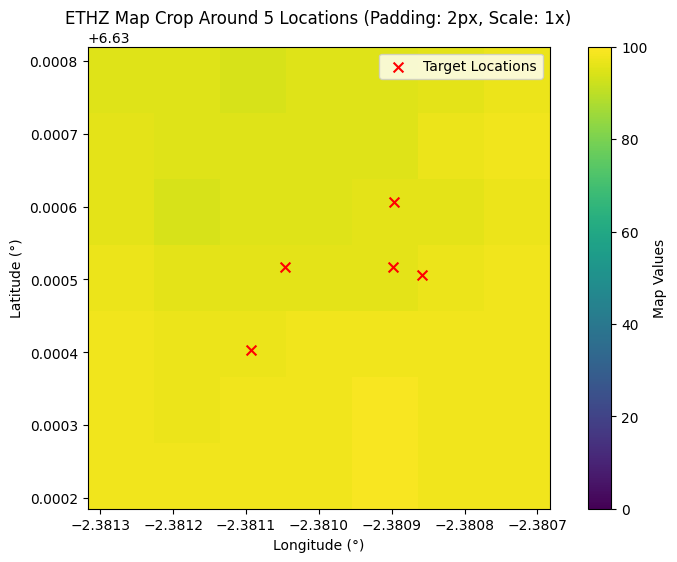

BI12


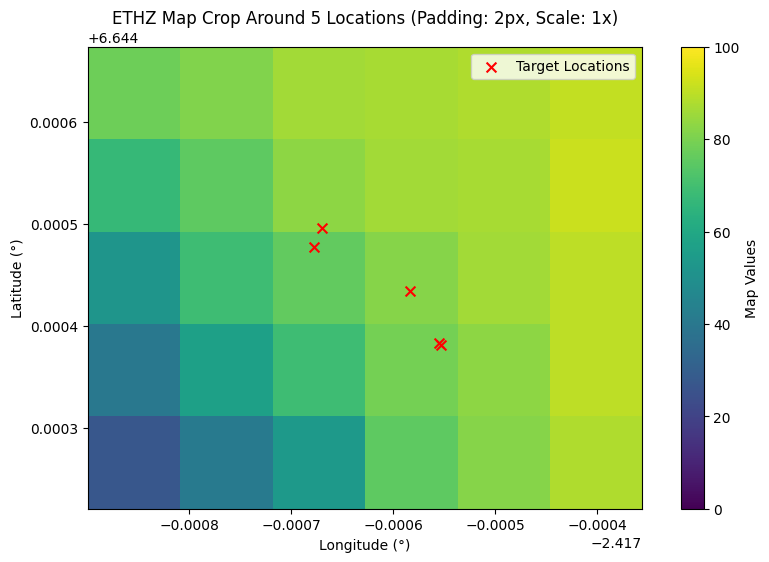

DU01


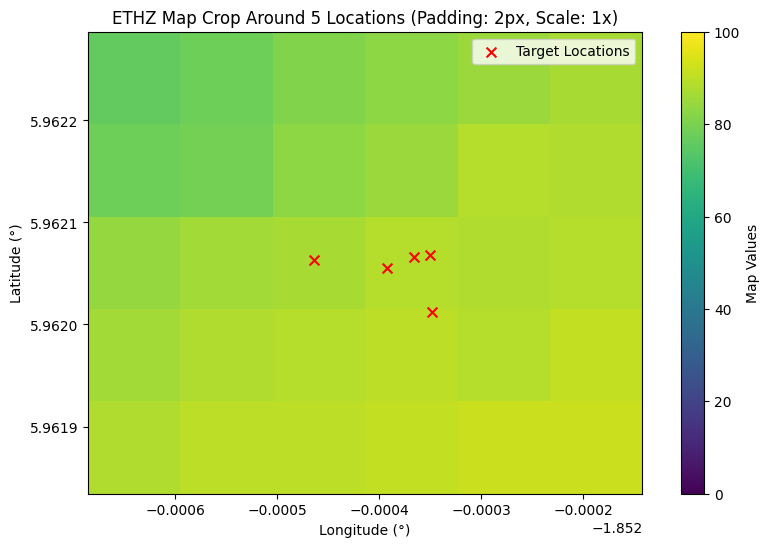

DU02


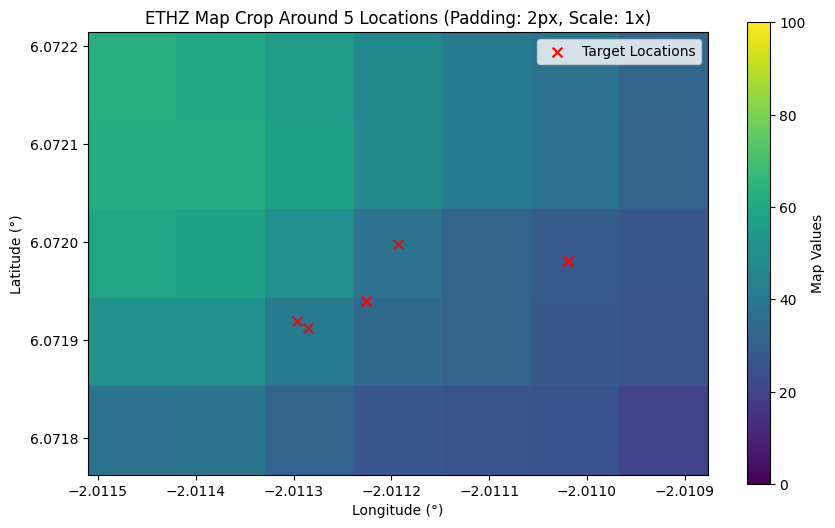

DU03


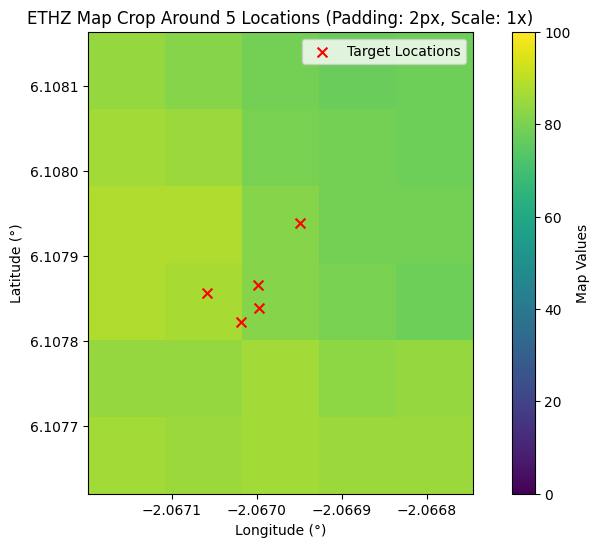

DU04


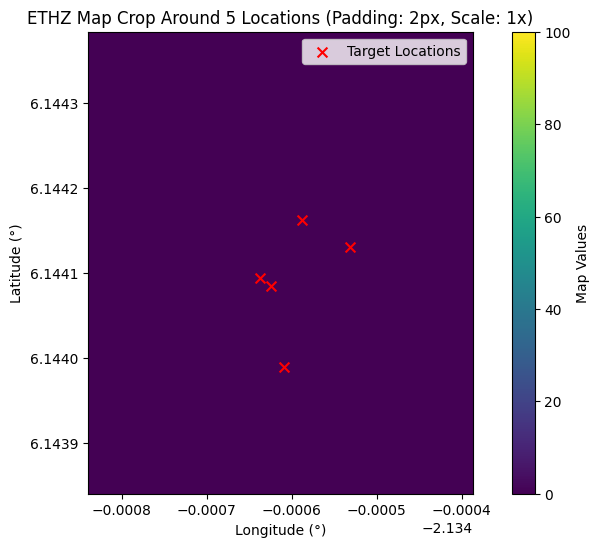

DU05


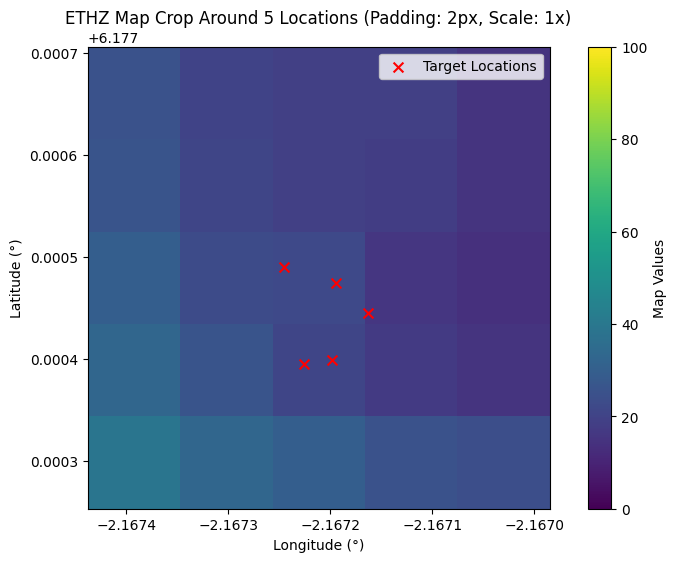

DU06


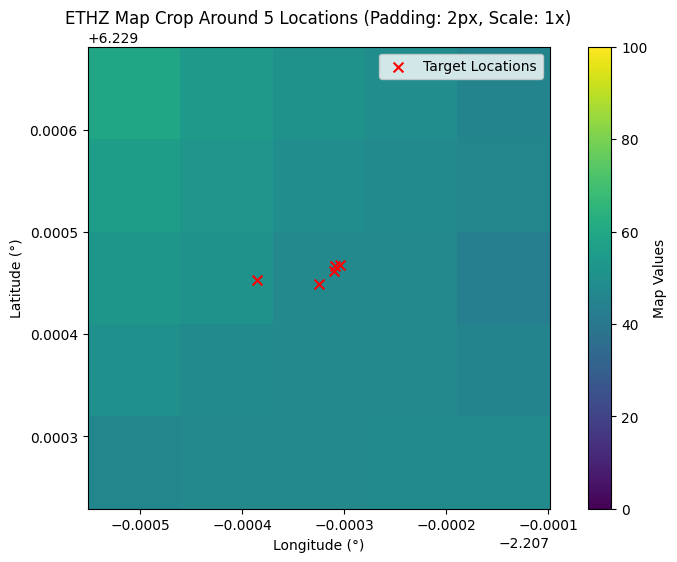

EN01


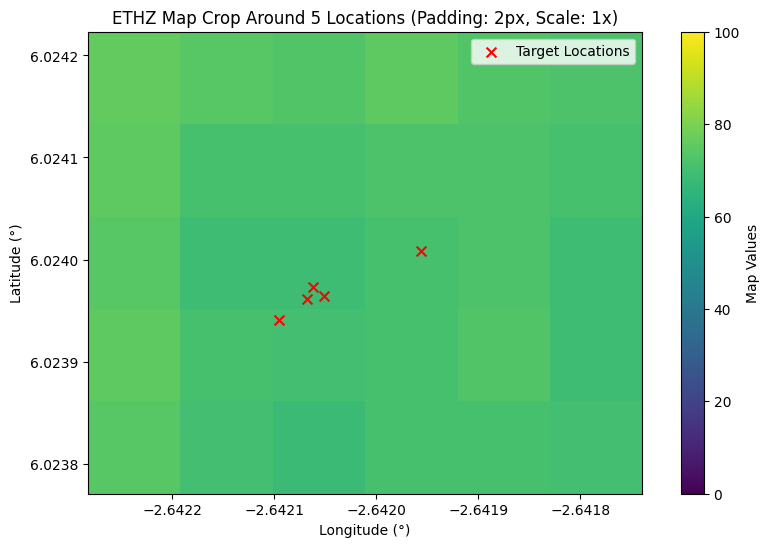

EN02


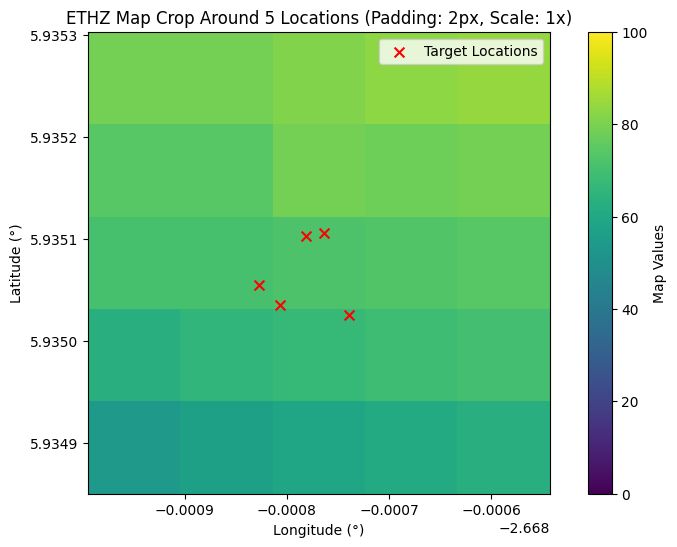

EN03


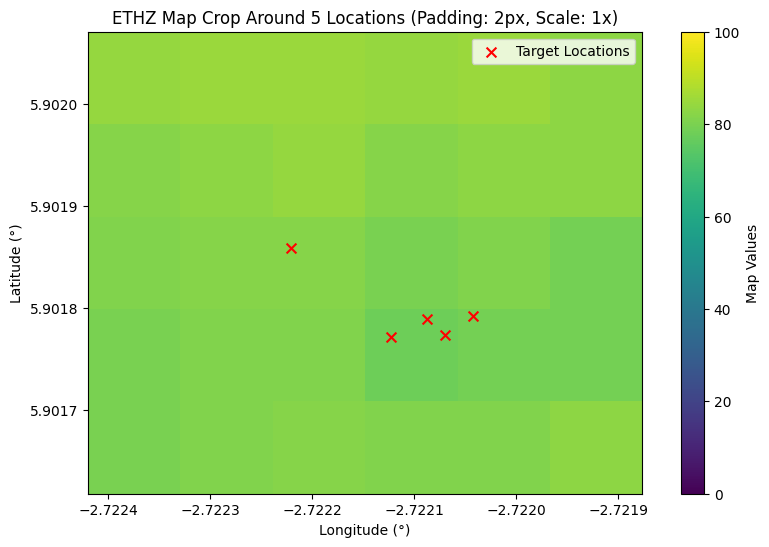

EN04


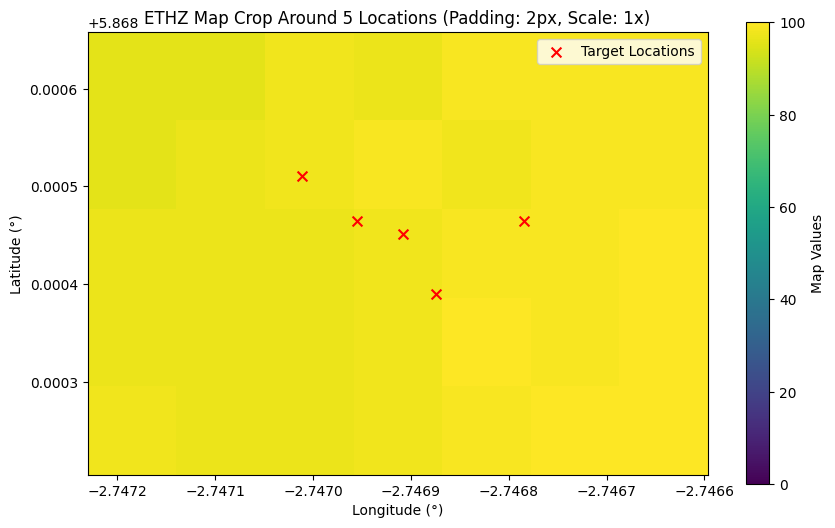

EN05


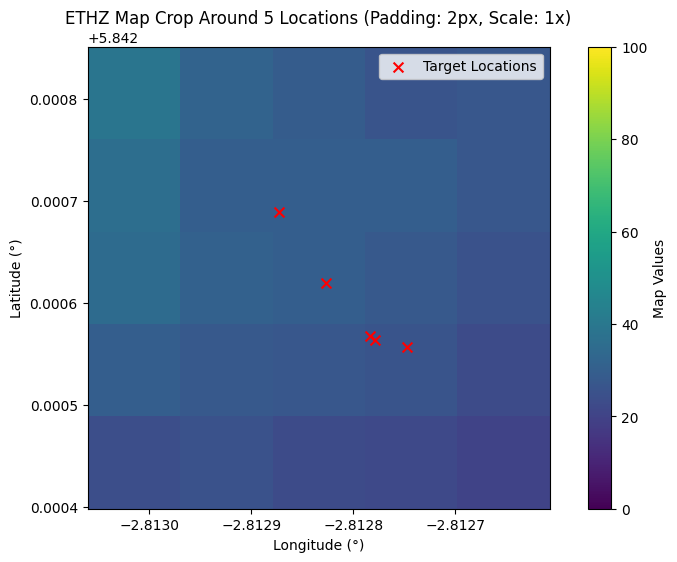

EN06


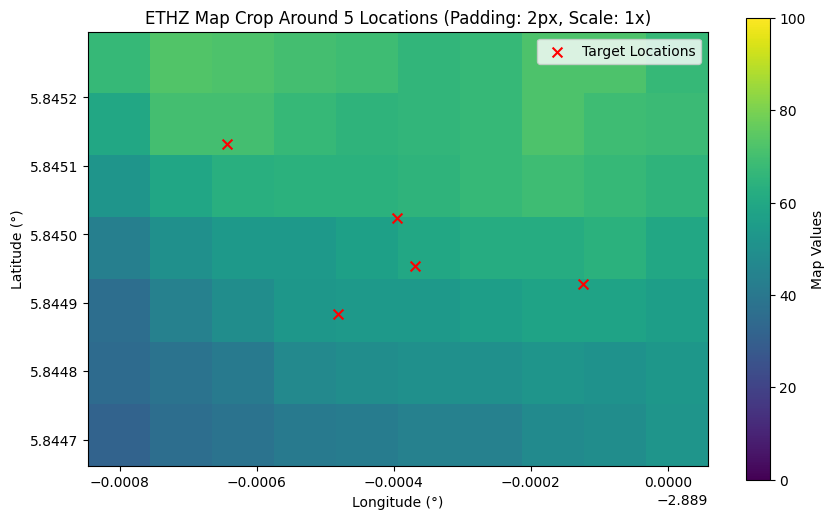

EN07


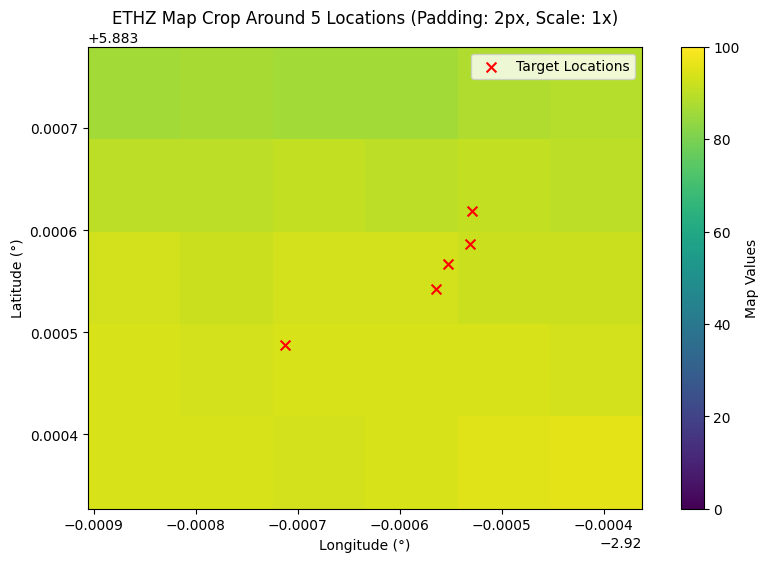

EN08


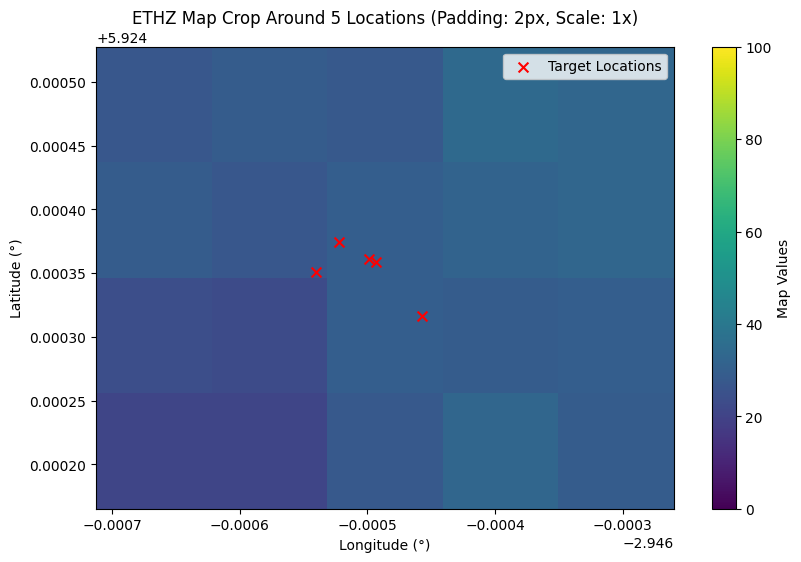

EN09


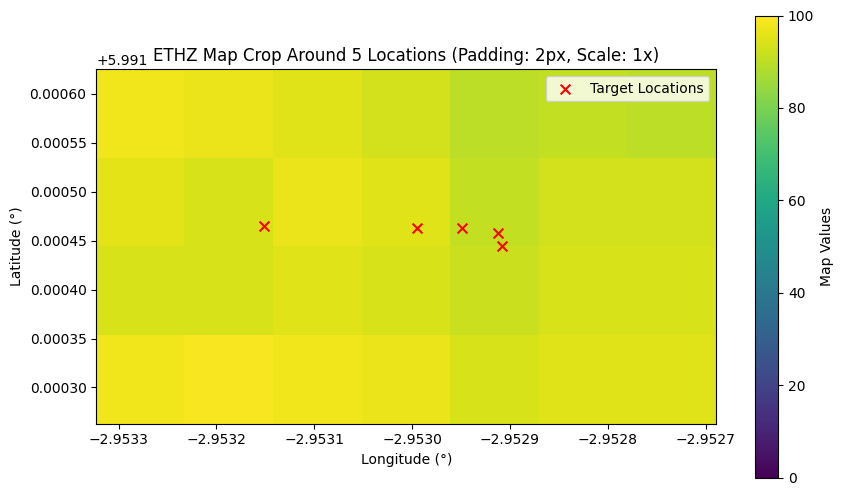

EN10


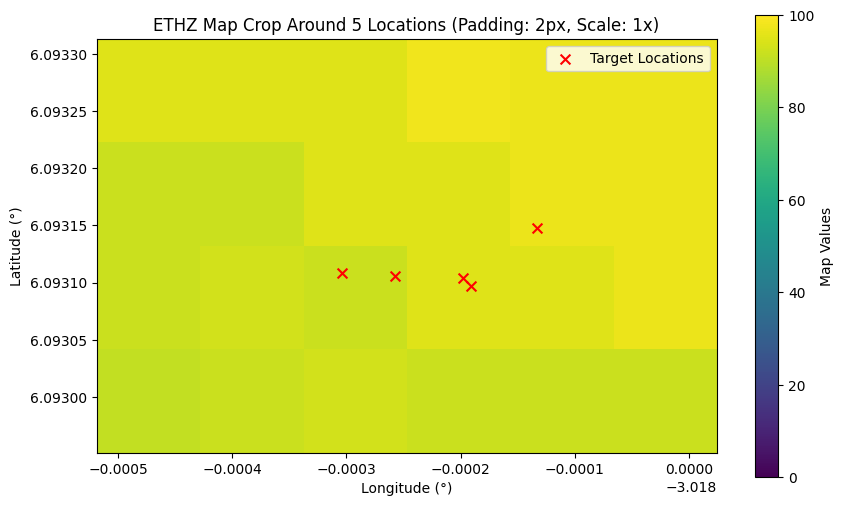

EN11


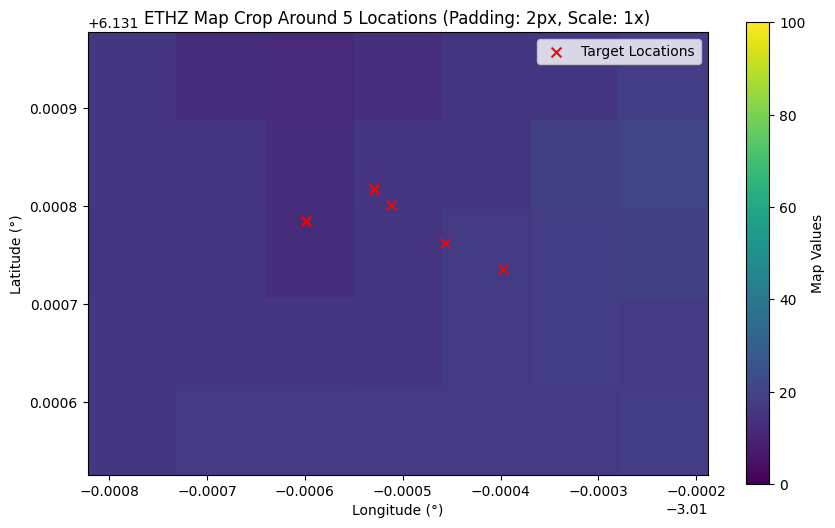

FO01


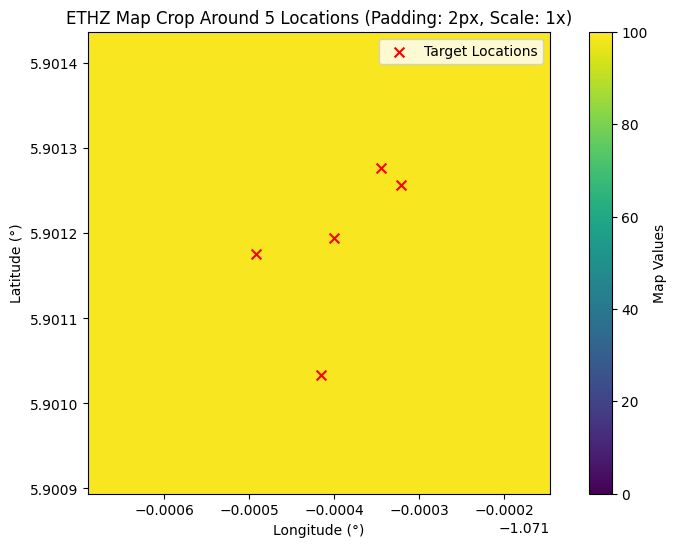

FO02


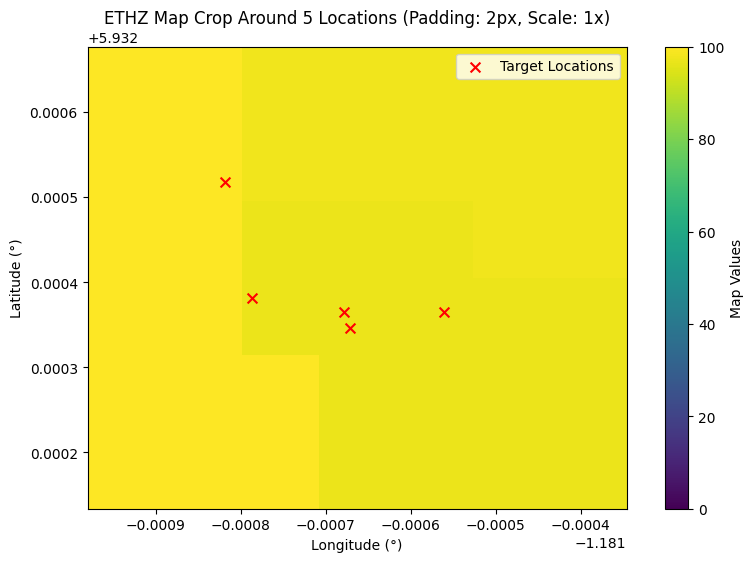

FO03


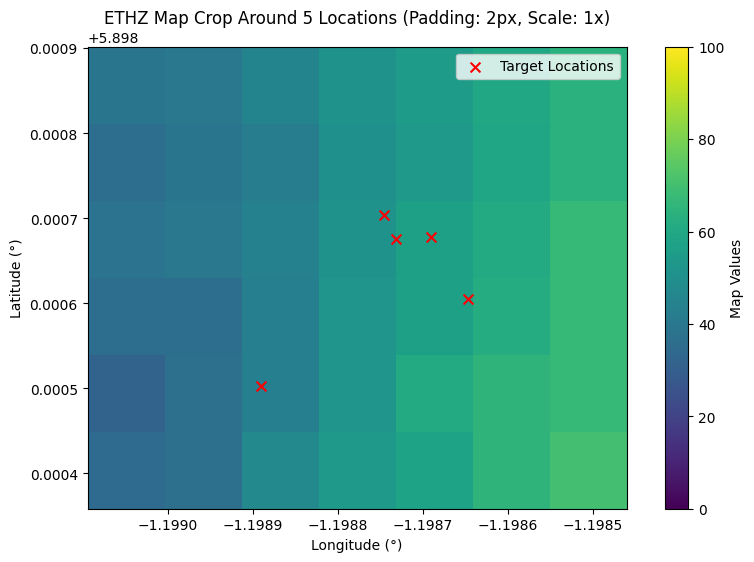

FO04


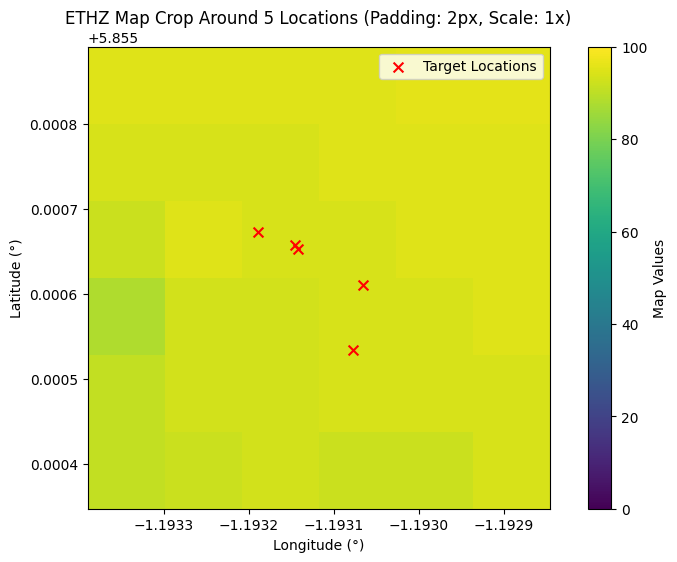

FO05


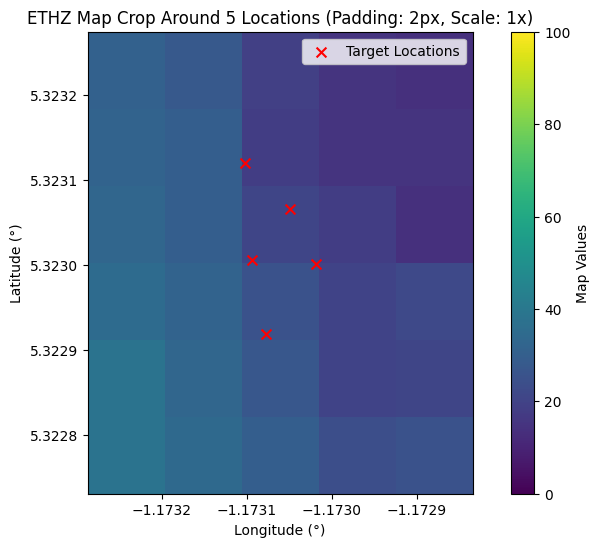

FO06


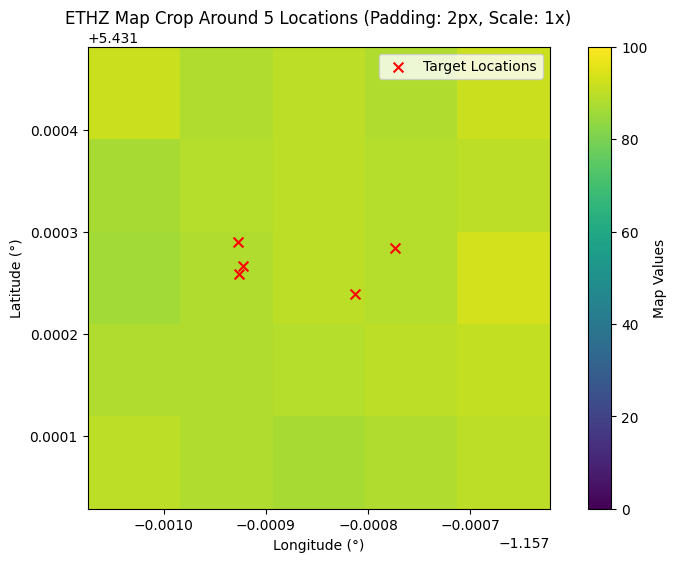

FO07


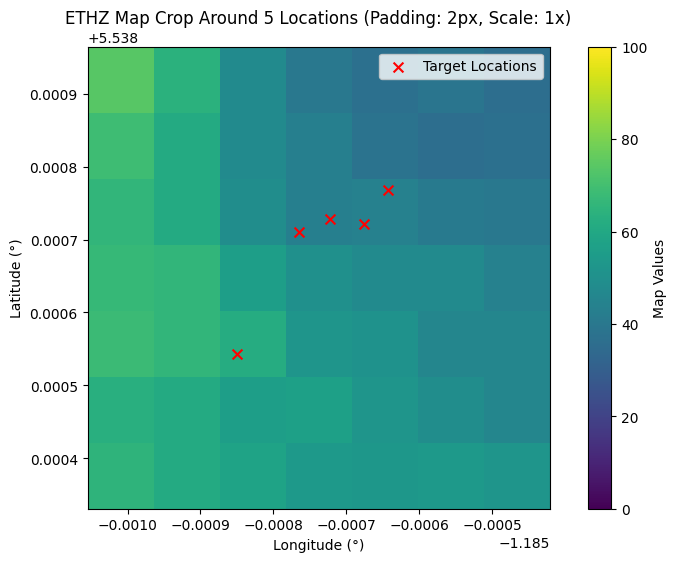

FO08


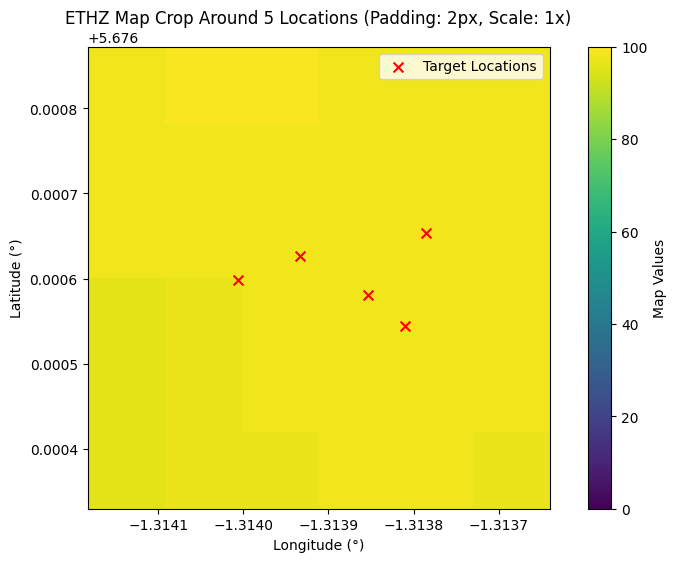

FO09


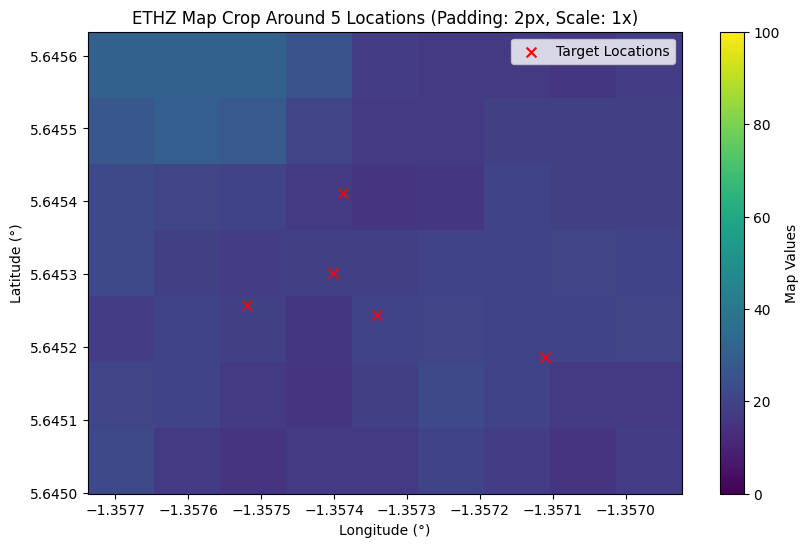

FO10


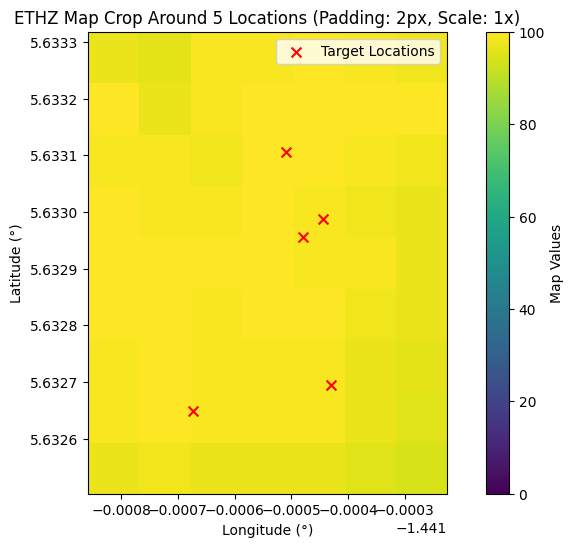

FO11


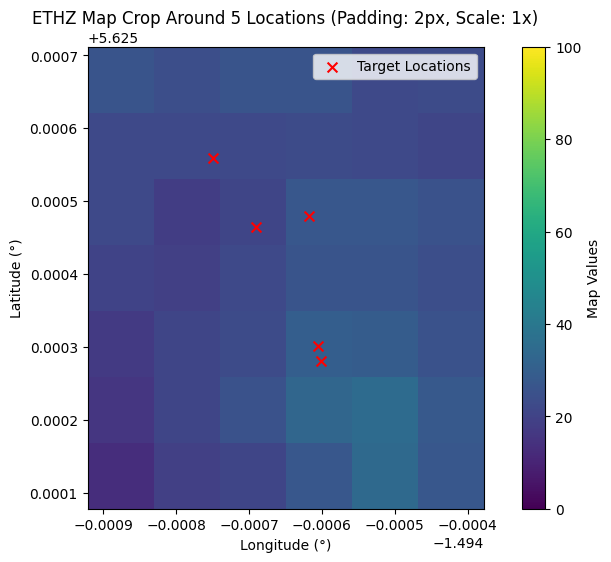

FO12


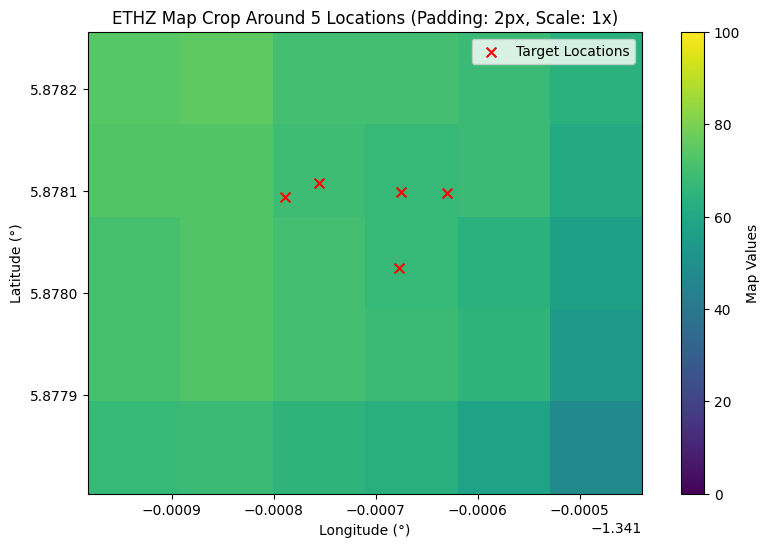

GO03


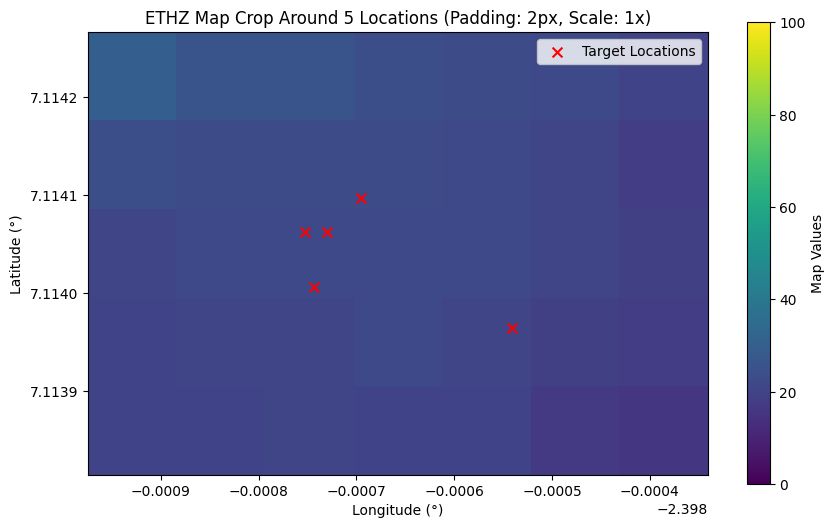

GO04


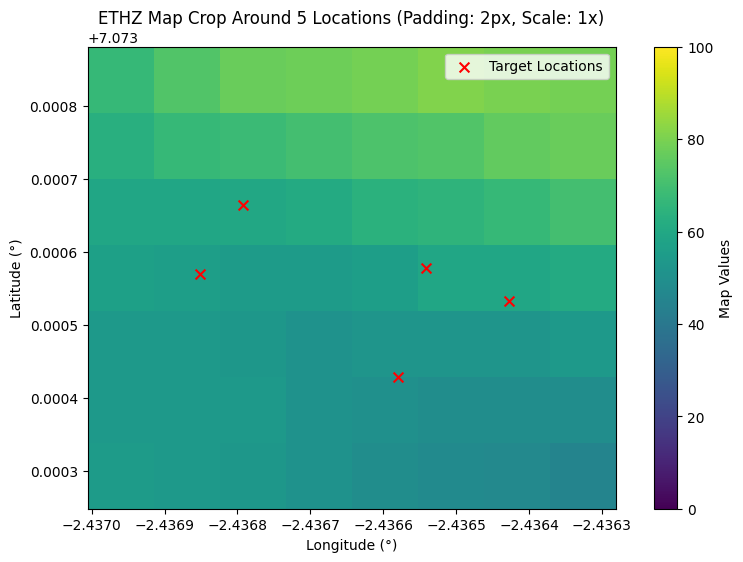

GO05


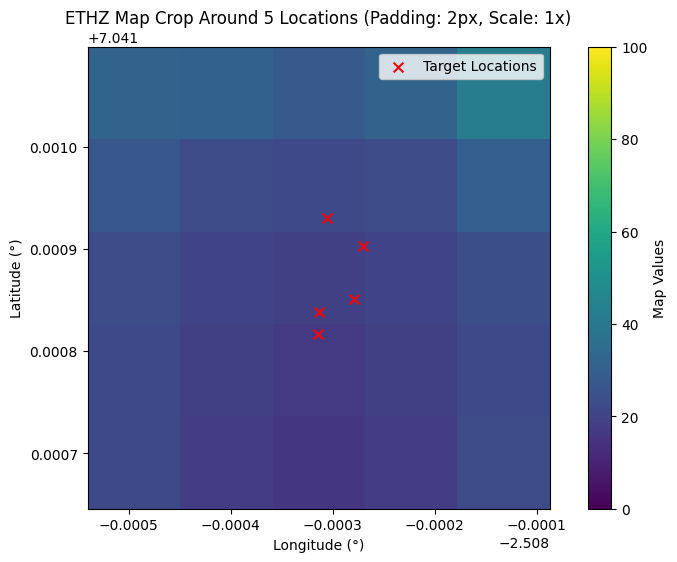

GO06


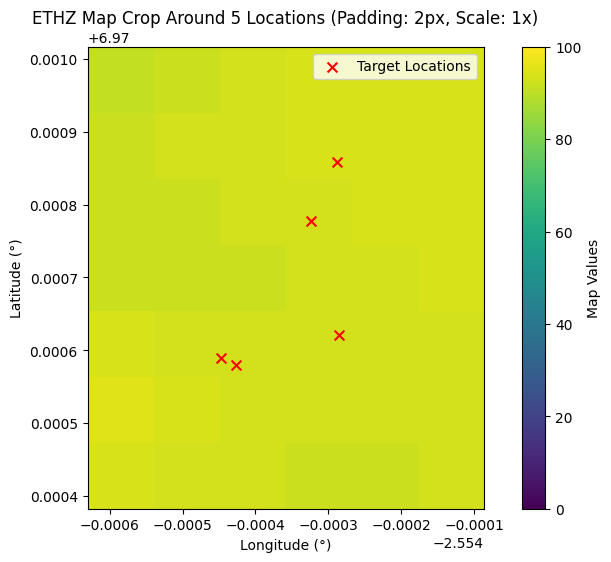

GO18


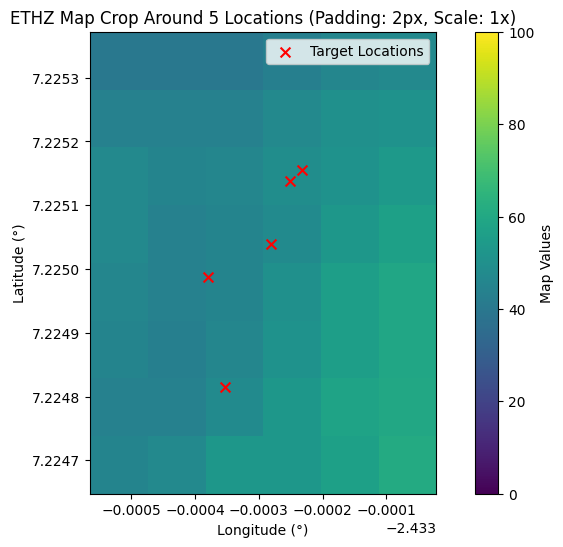

GO19


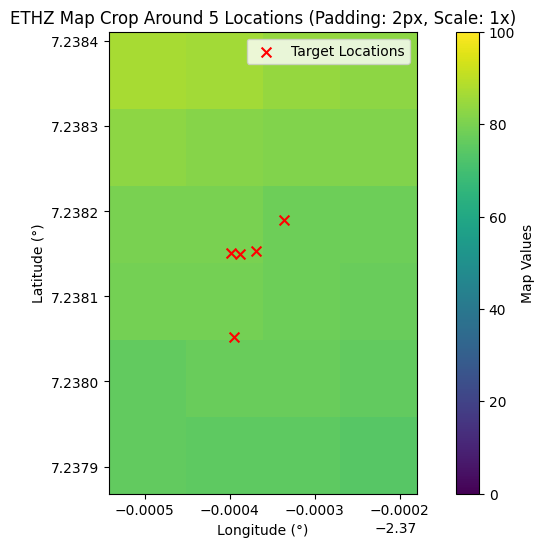

HU01


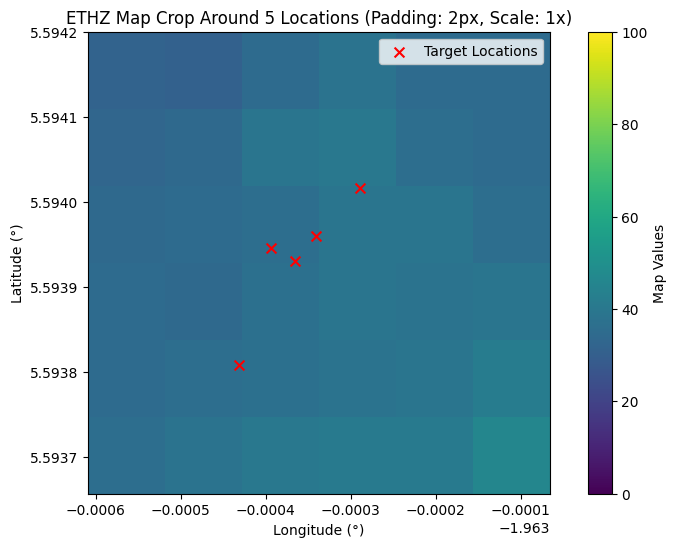

HU02


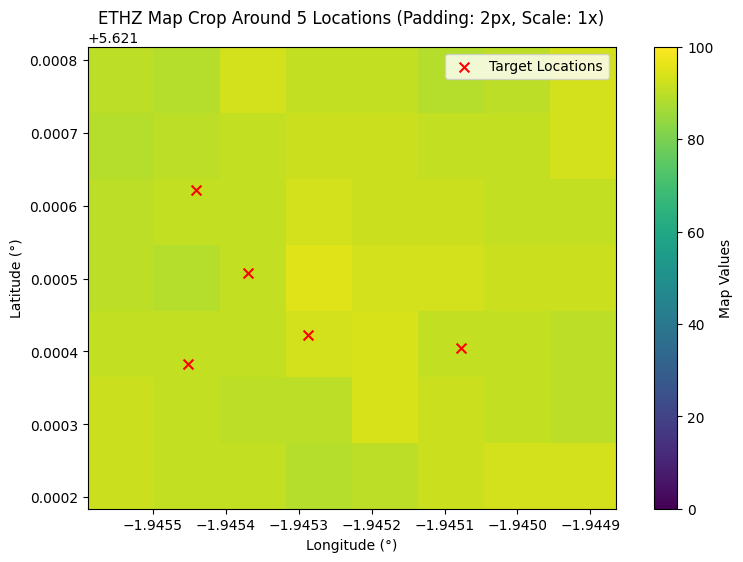

HU03


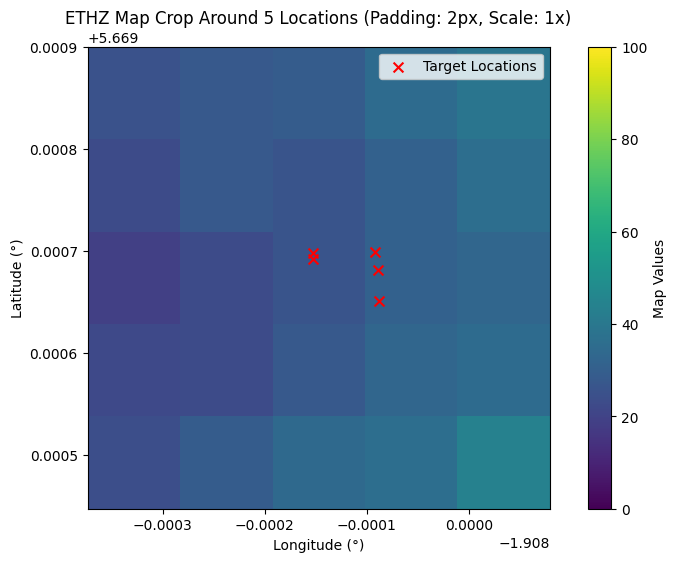

HU04


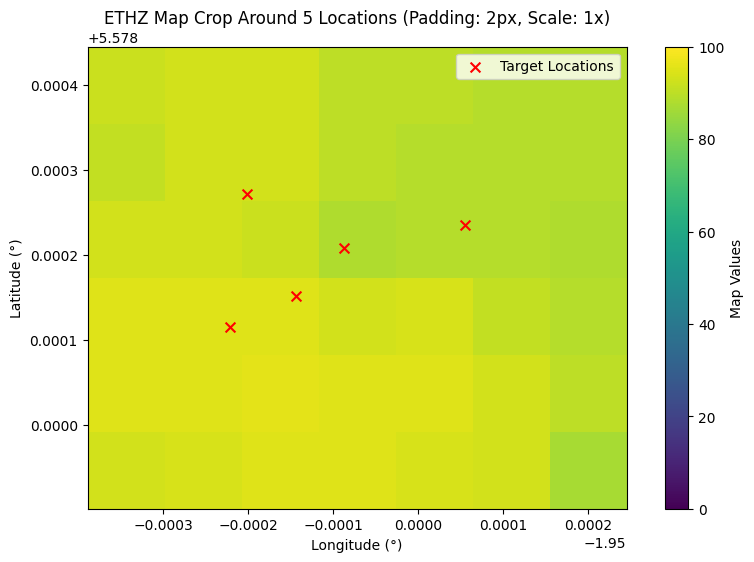

HU05


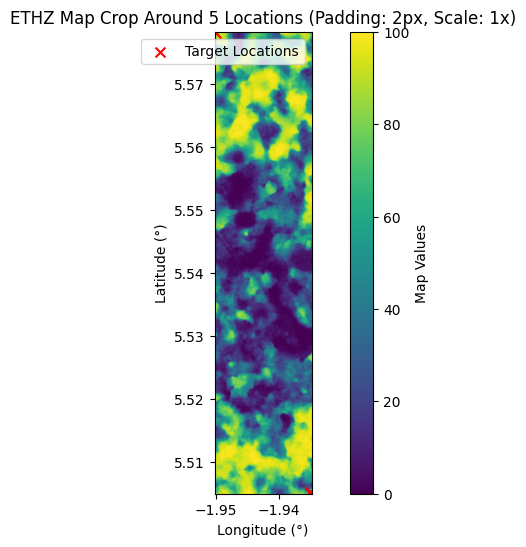

HU06


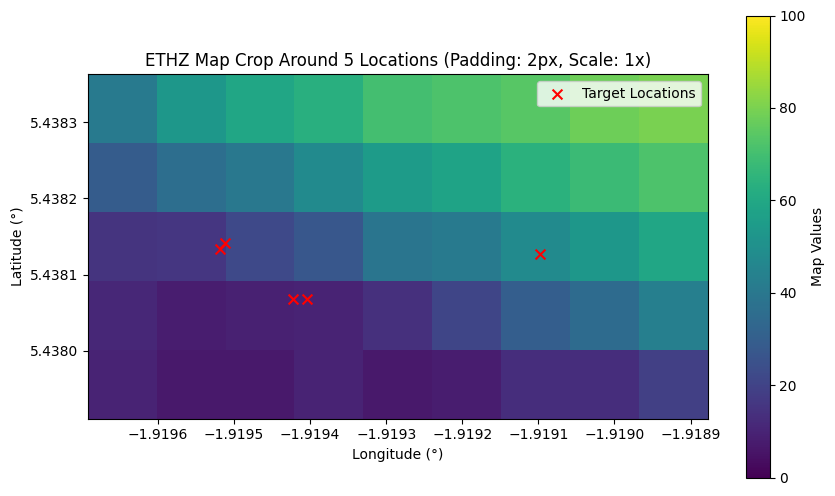

HU07


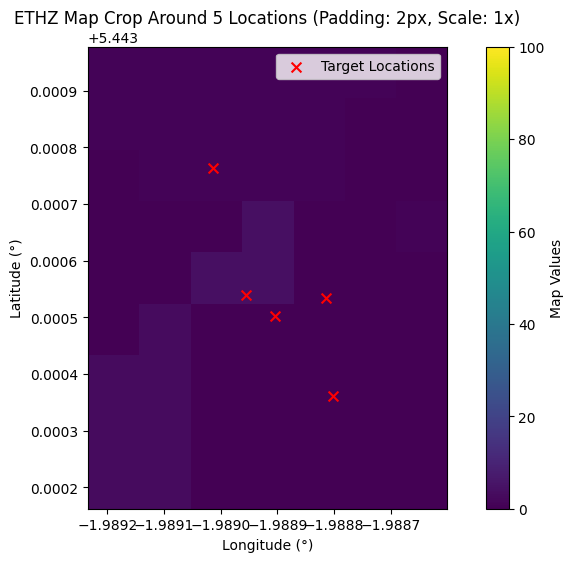

HU08


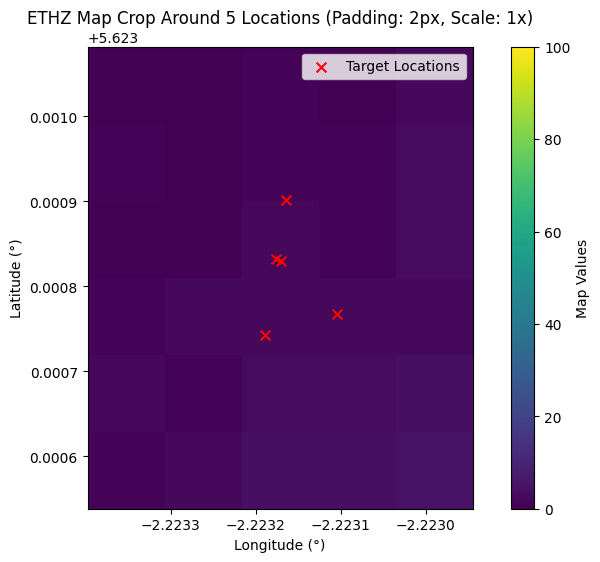

HU09


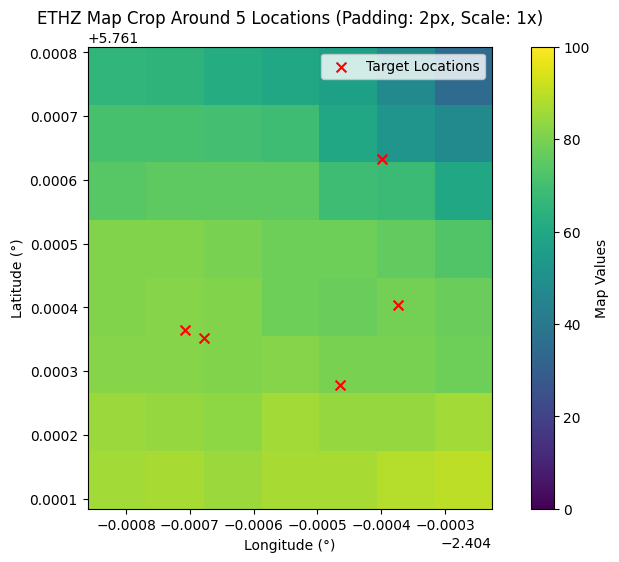

JU01


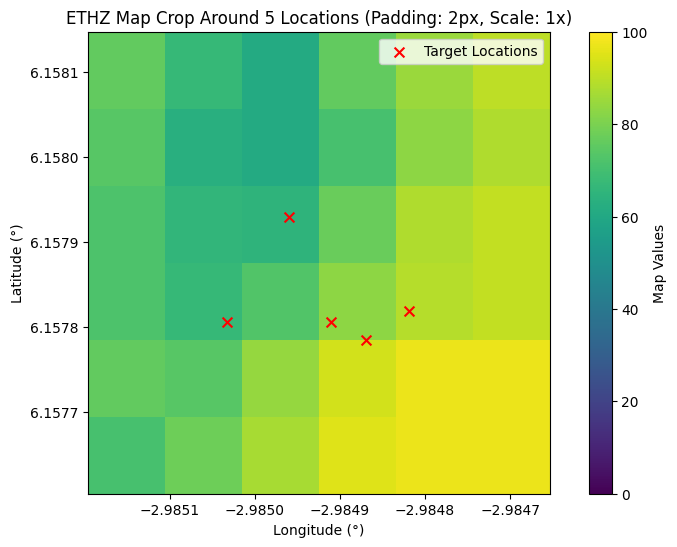

JU02


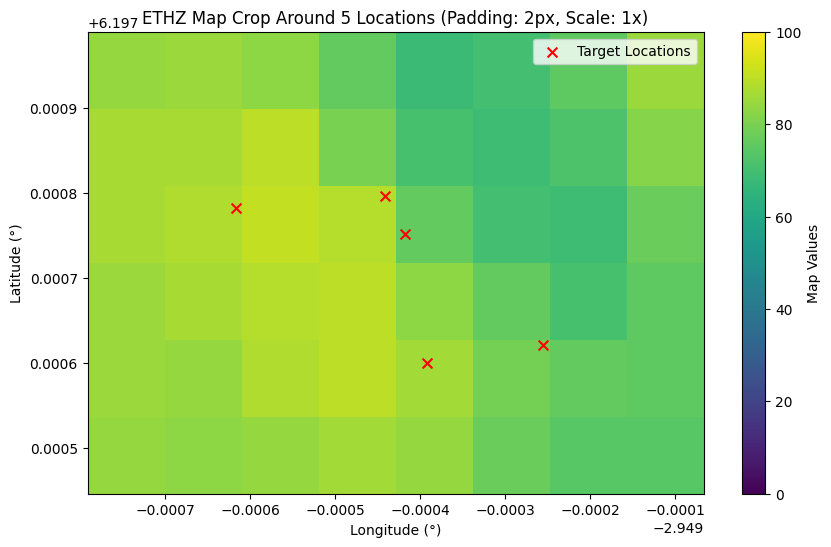

JU03


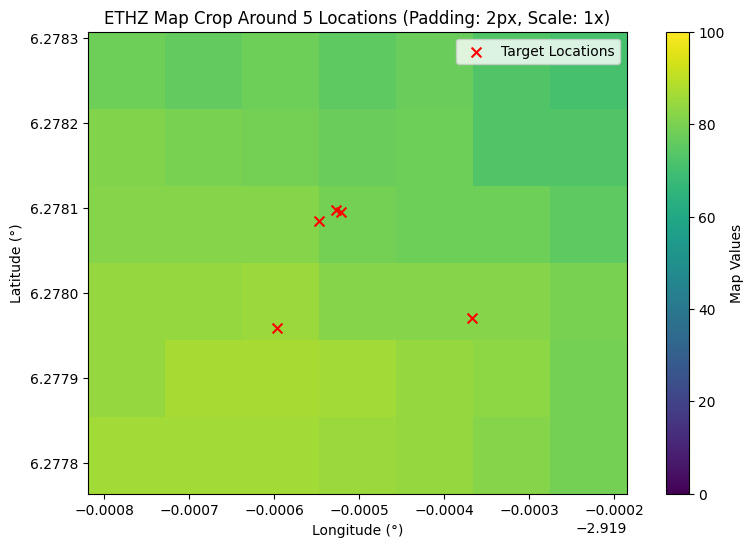

JU04


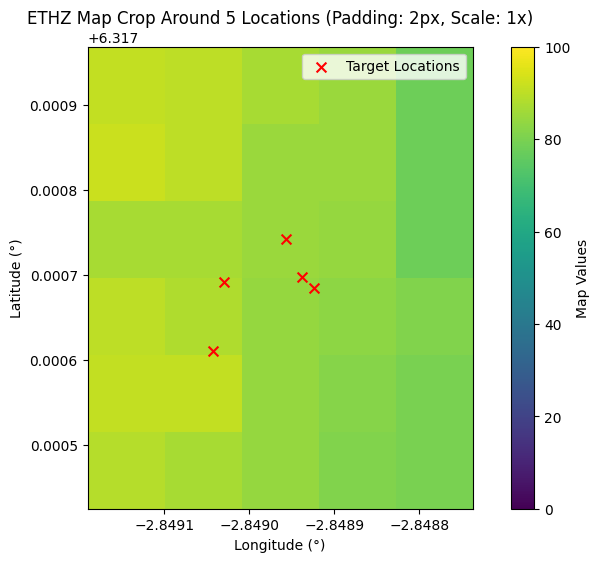

JU05


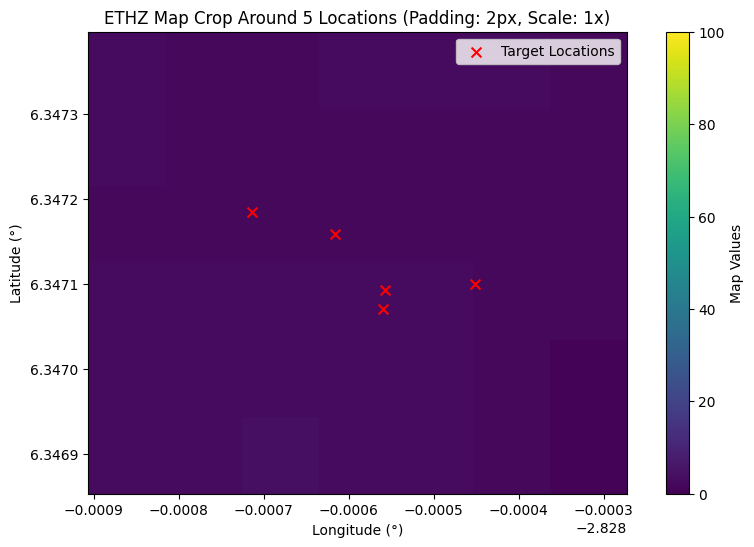

JU06


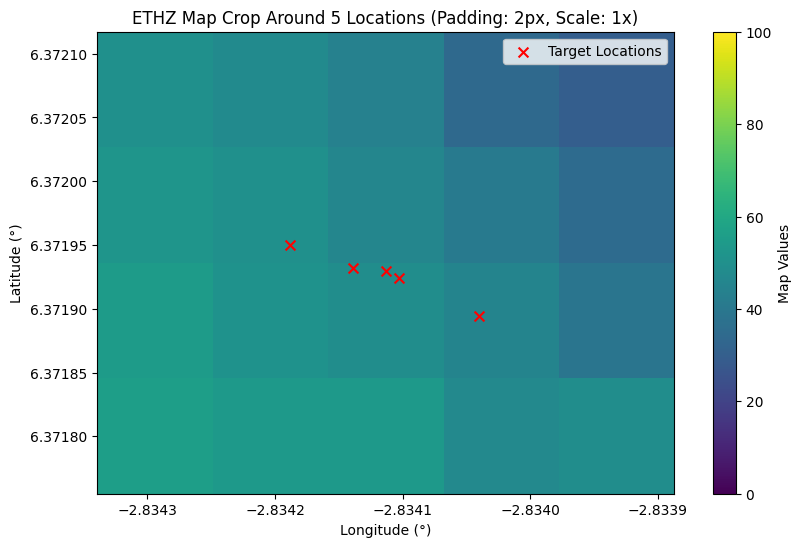

JU07


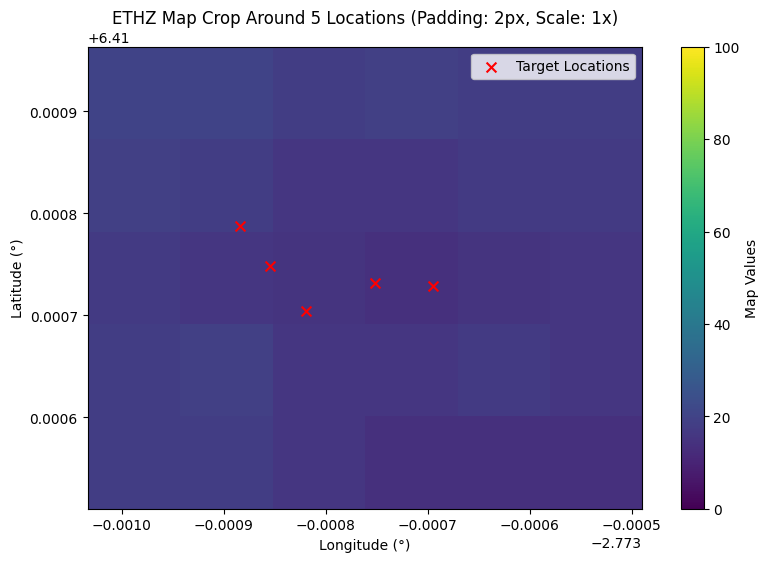

JU08


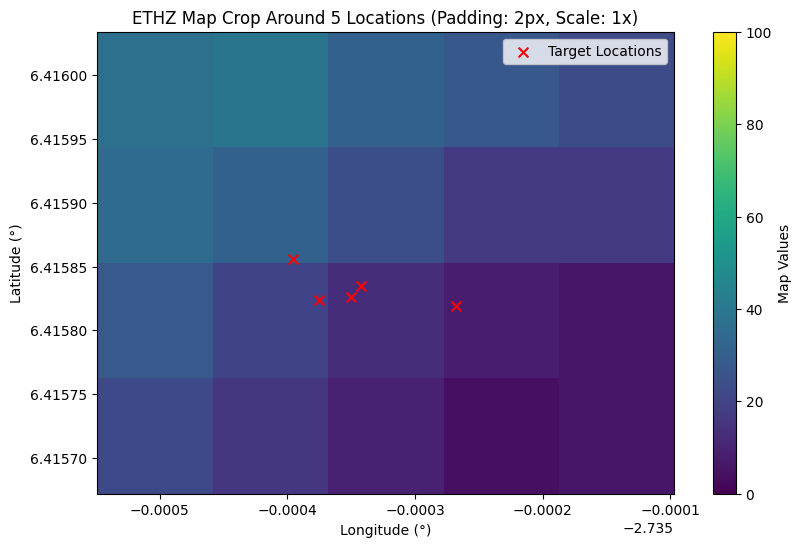

KU01


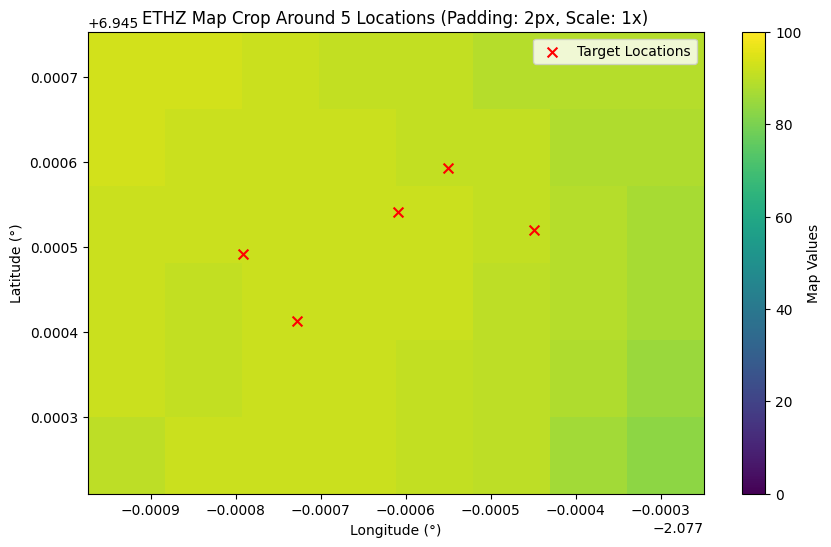

KU02


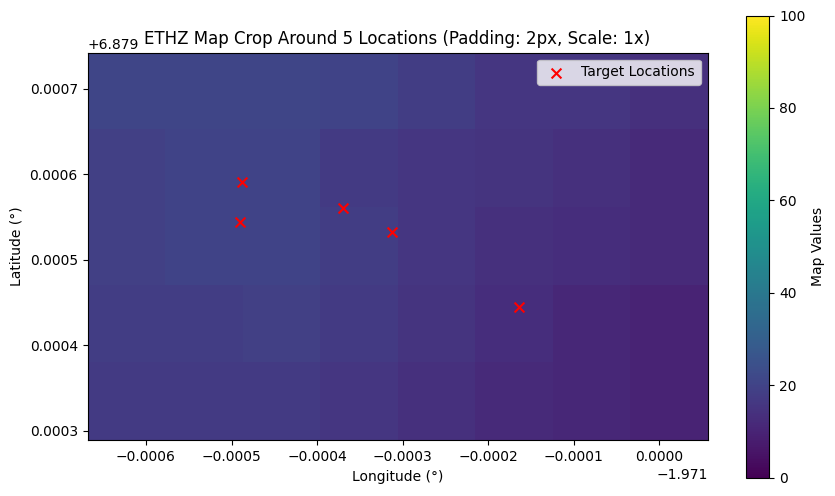

KU03


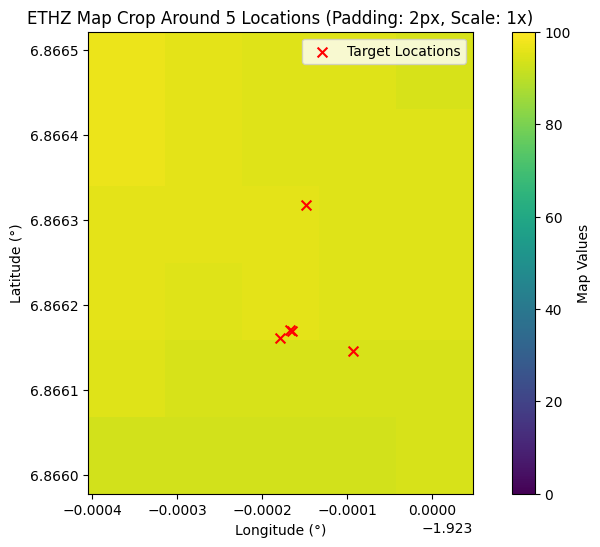

KU04


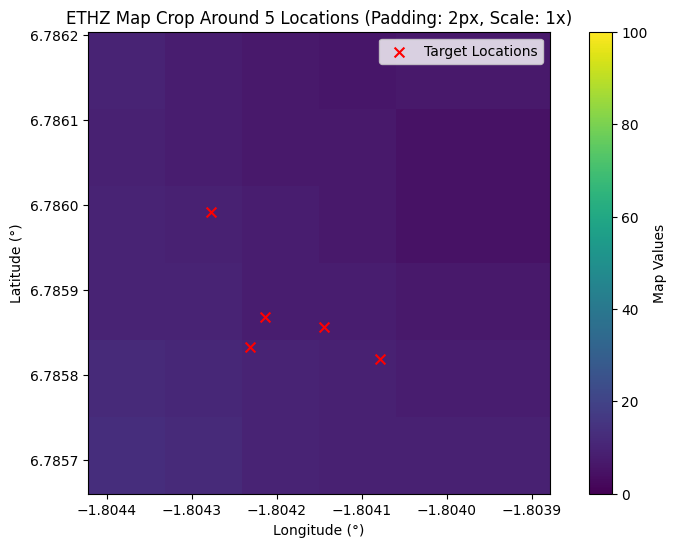

KU05


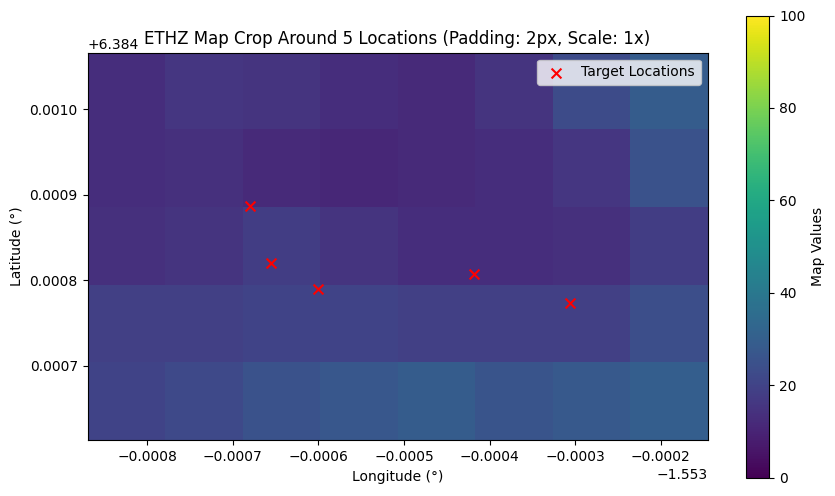

KU06


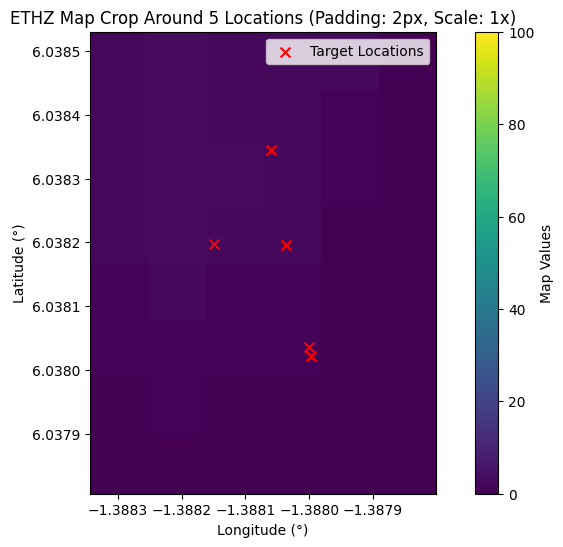

KU07


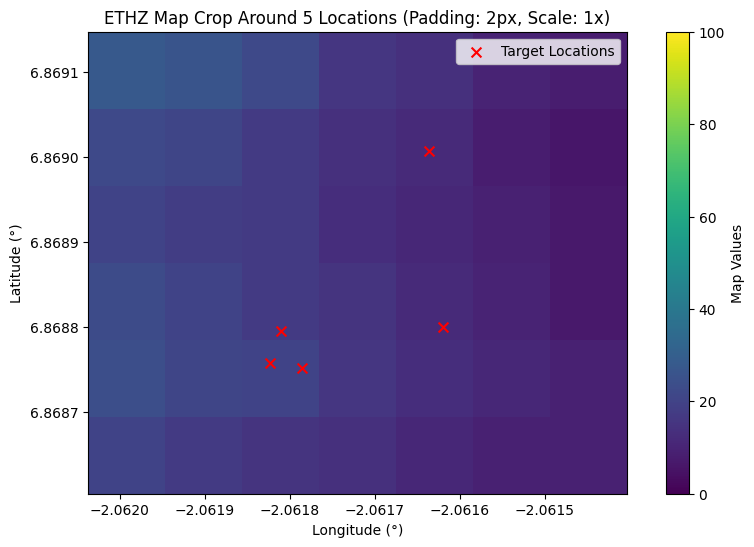

KU08


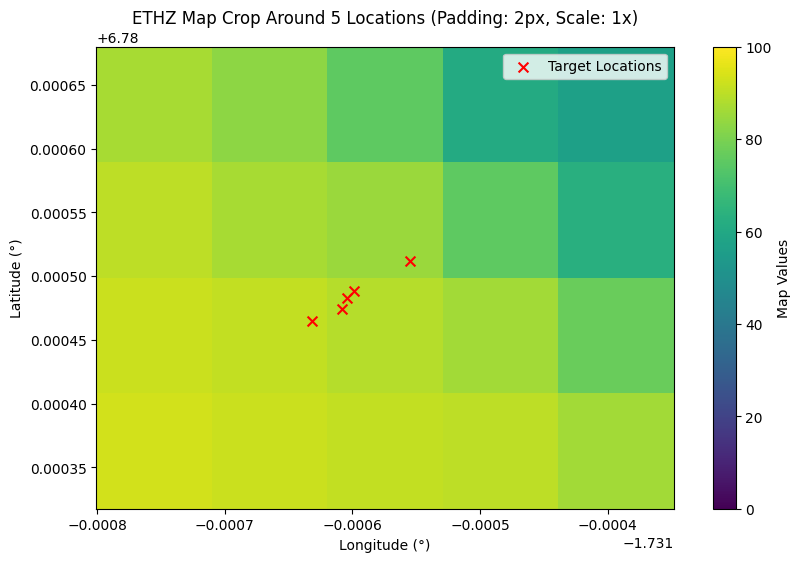

KU09


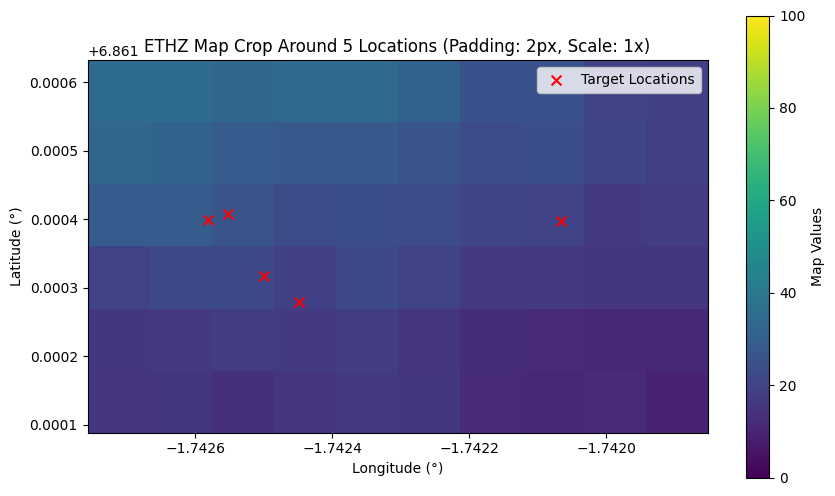

KU10


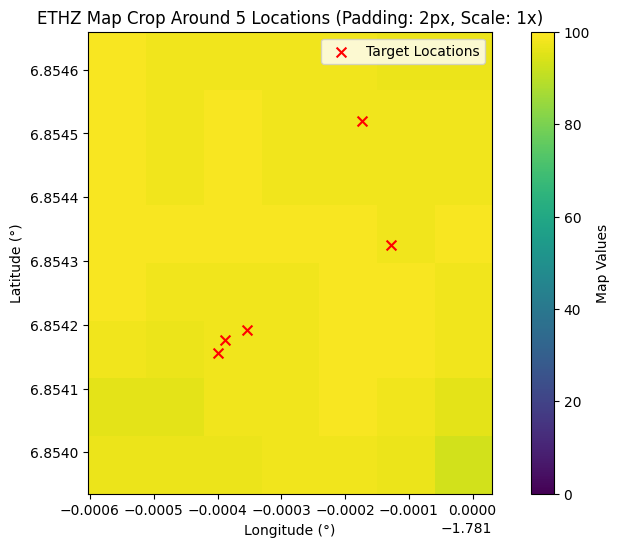

KU11


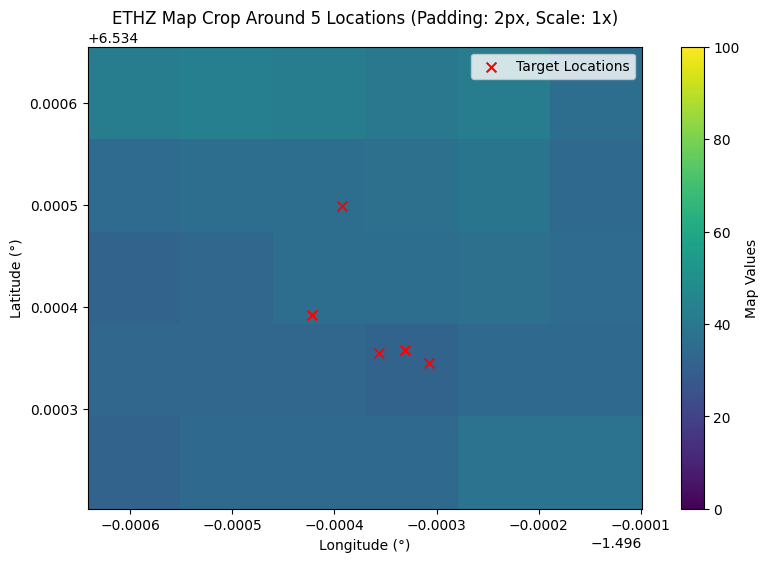

KU12


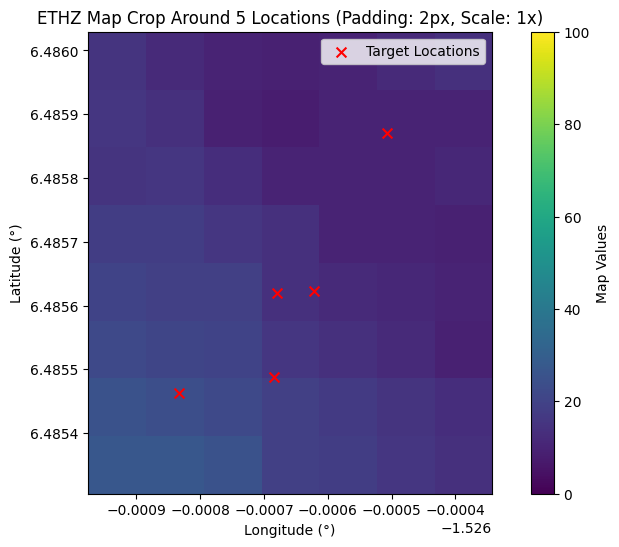

KU13


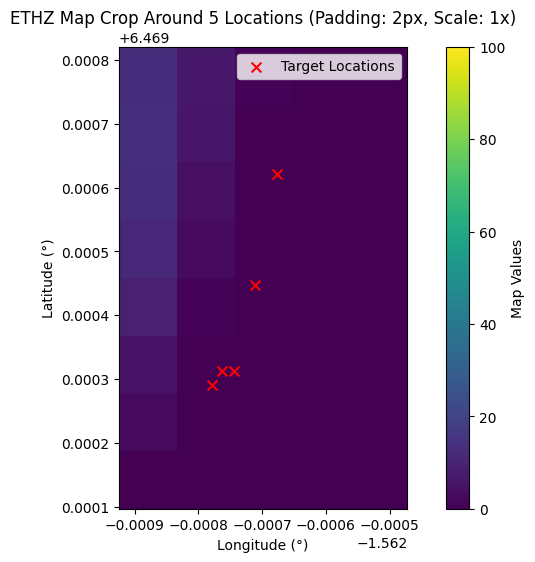

NE01


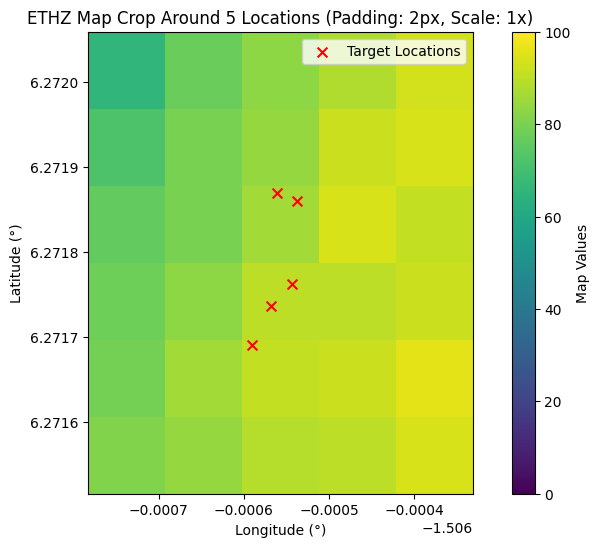

NE02


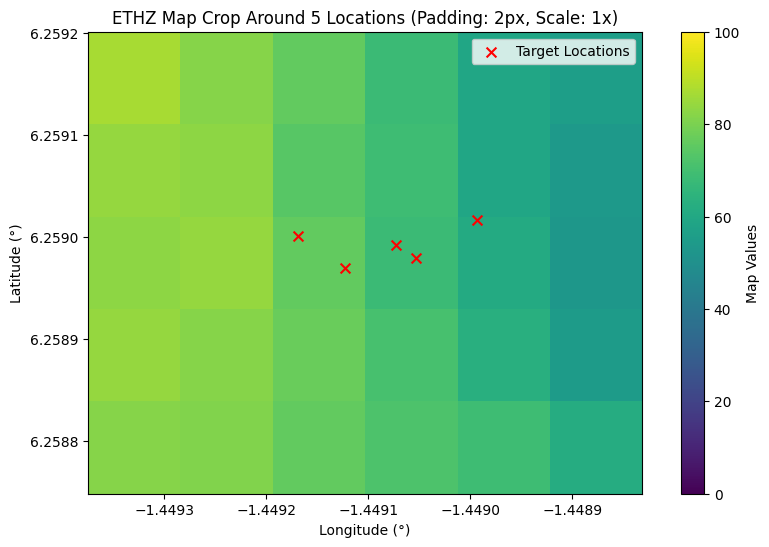

NE03


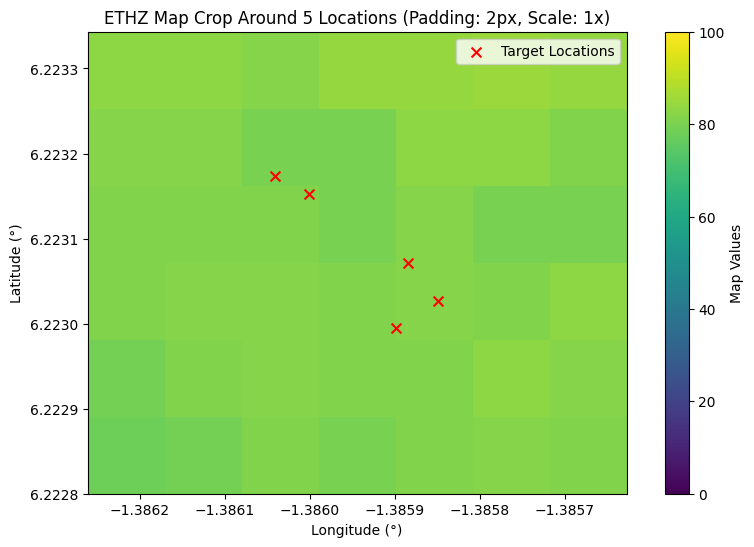

NE04


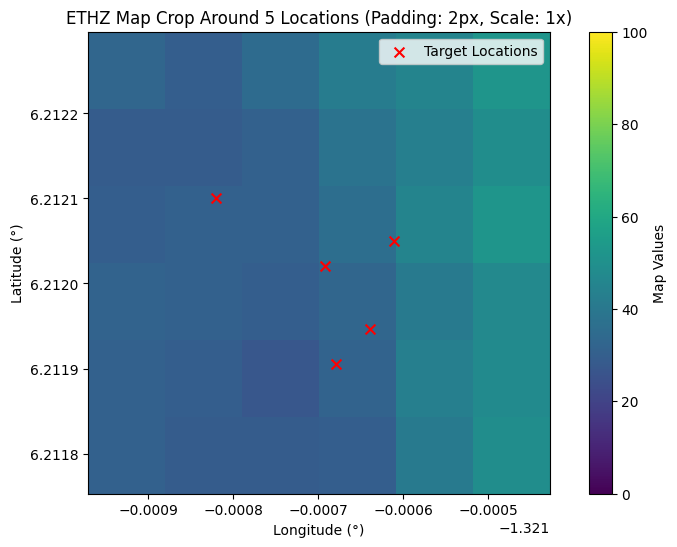

NE05


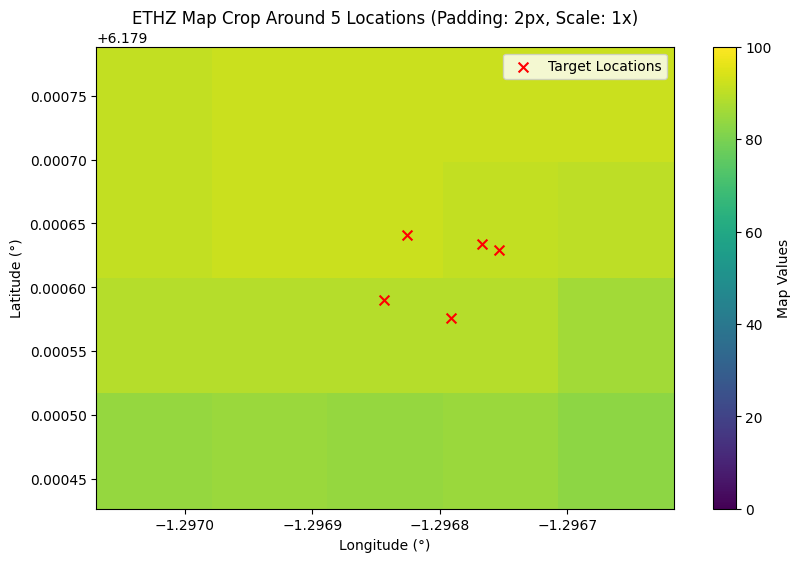

NE06


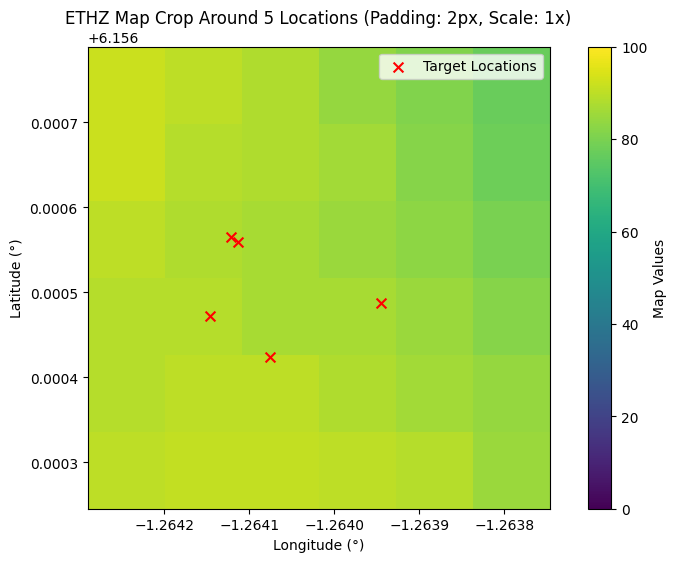

NE07


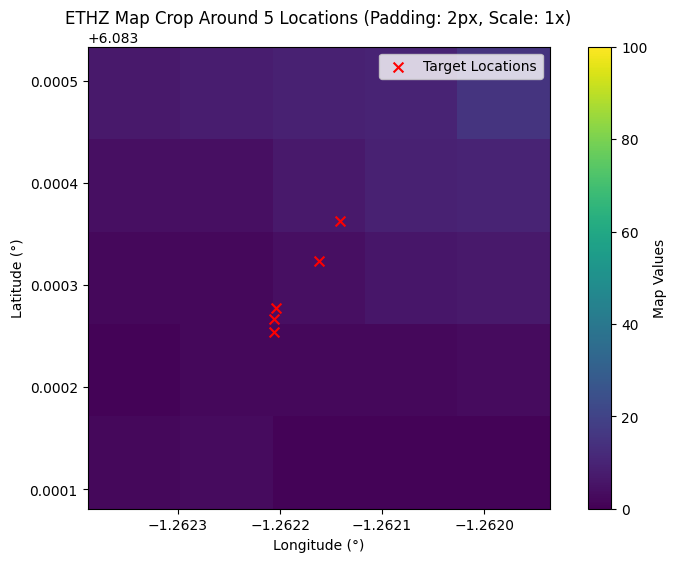

NE08


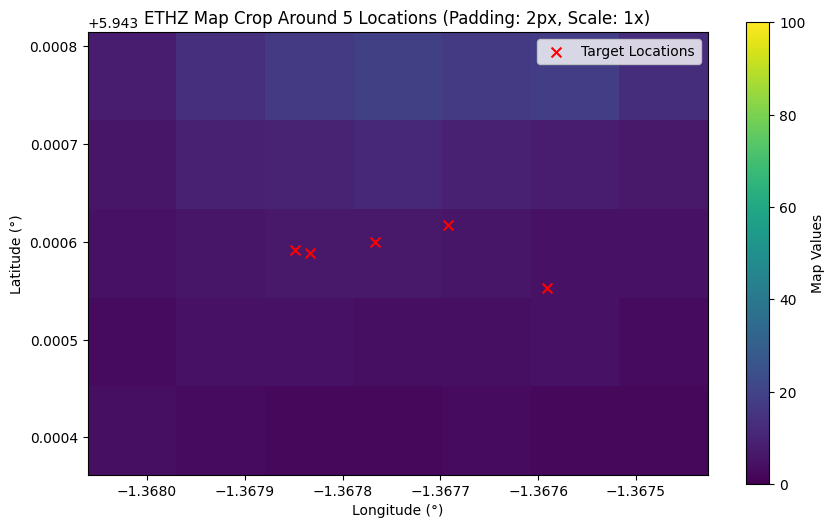

SA01


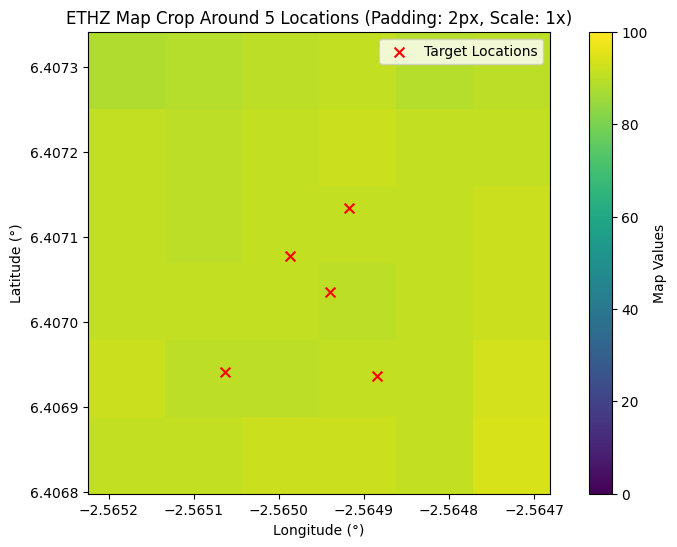

SB01


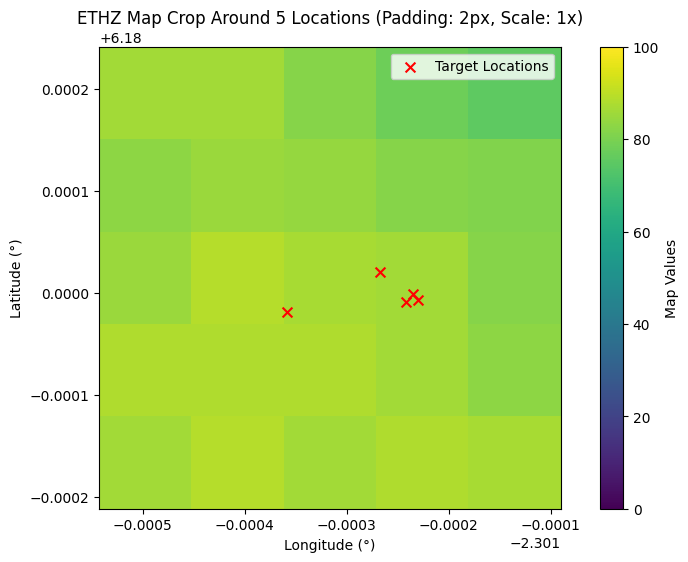

SB02


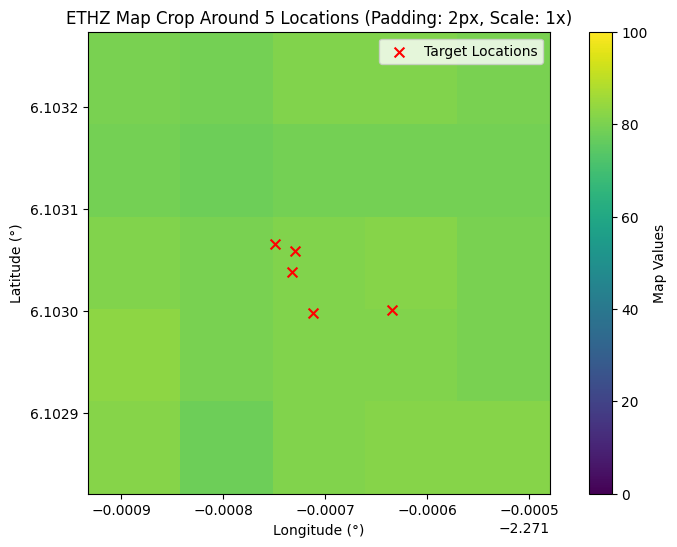

SB03


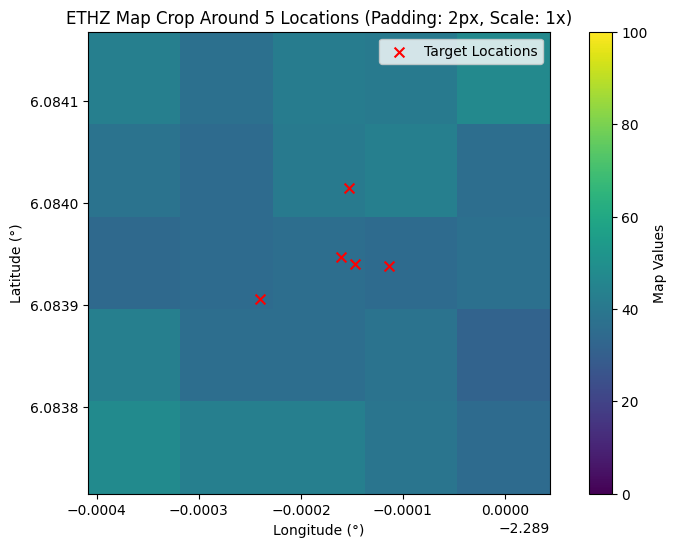

SB04


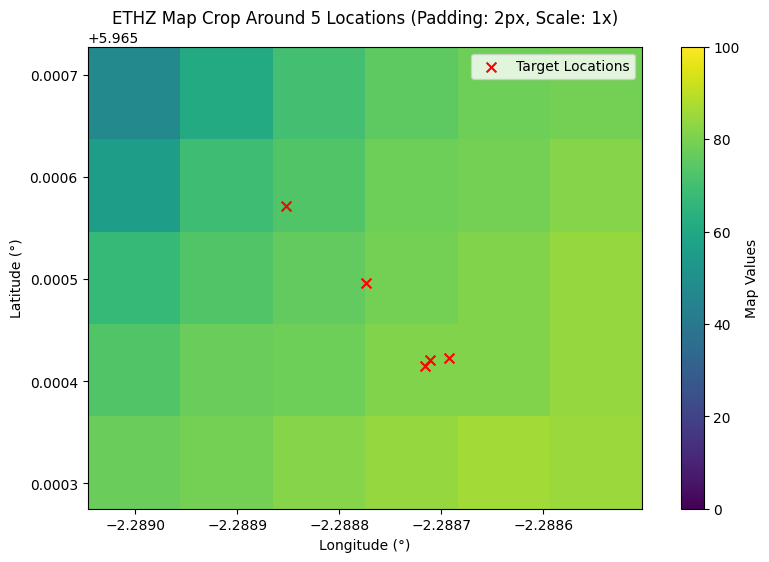

SB05


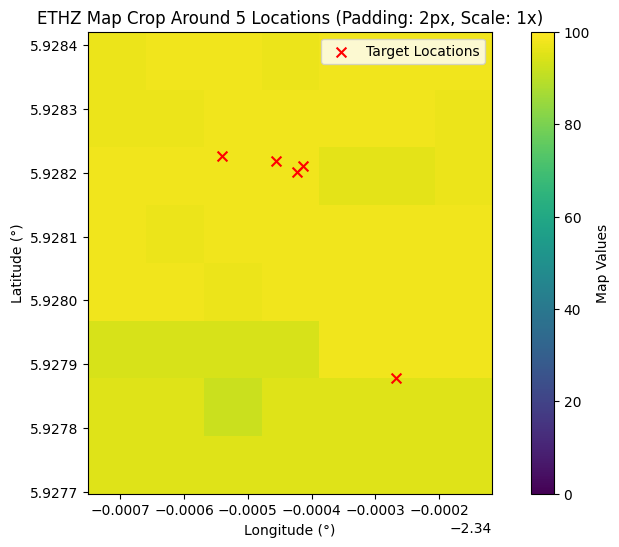

SB06


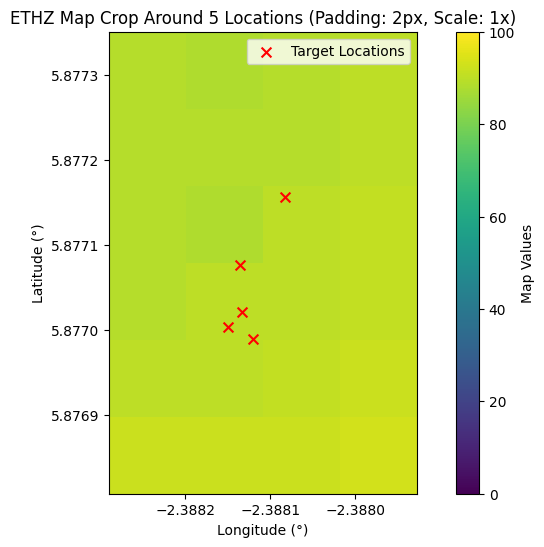

SB07


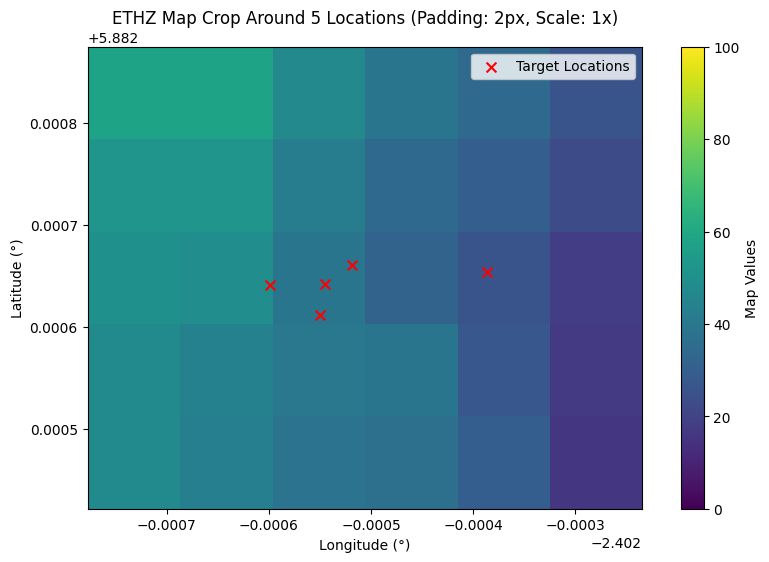

SB08


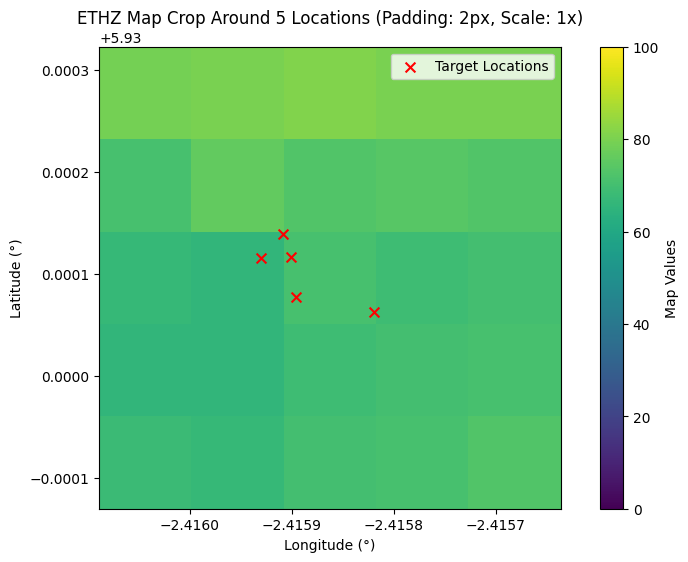

SB09


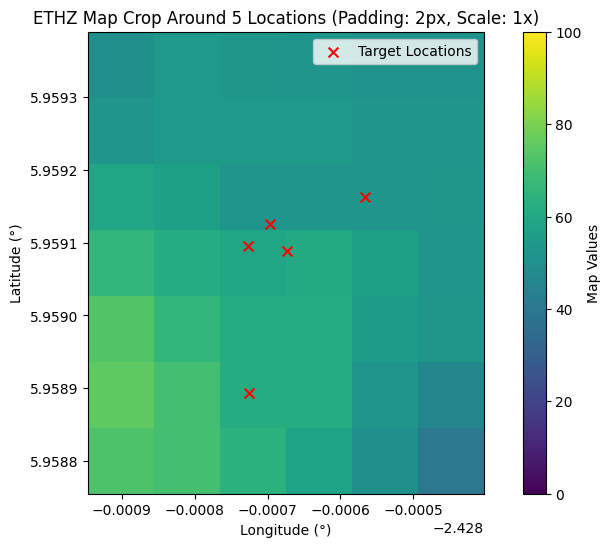

SB10


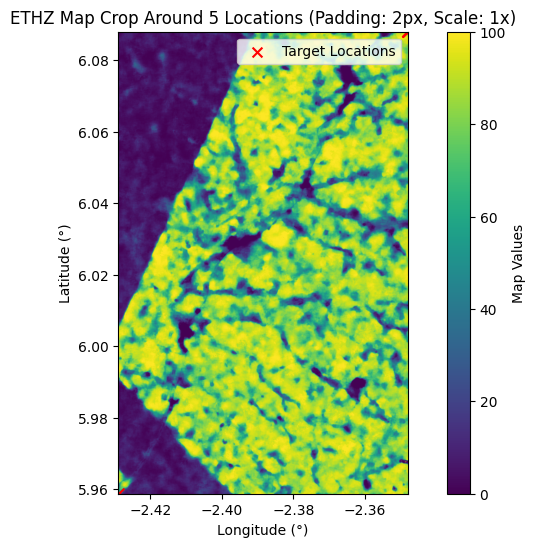

SB11


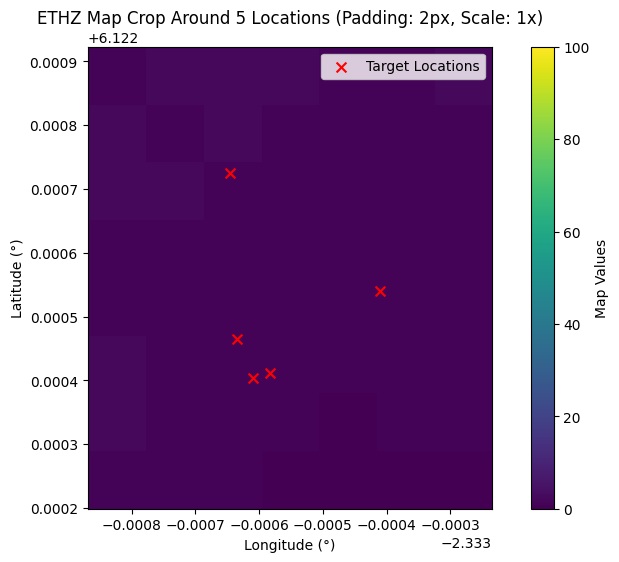

SB12


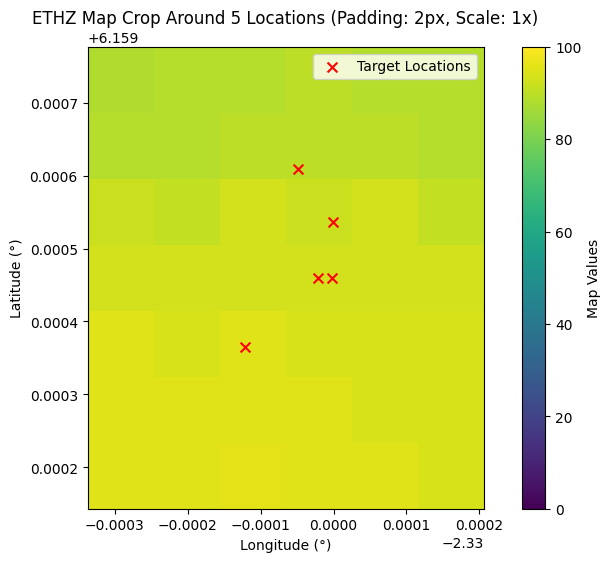

SB13


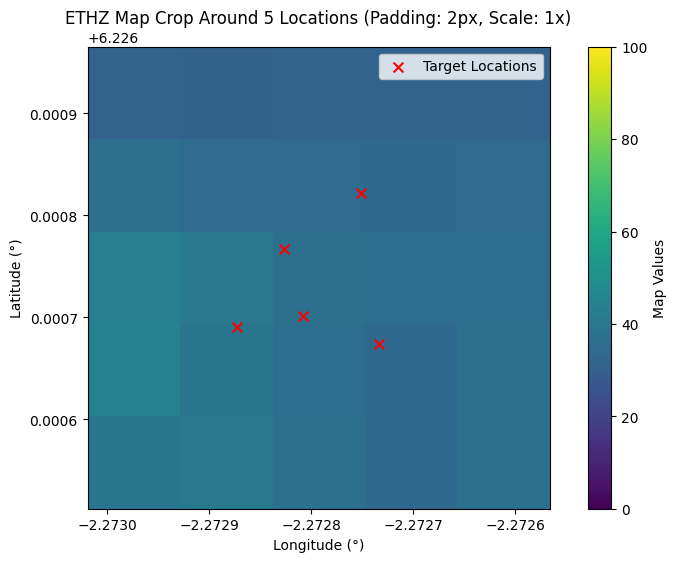

SE01


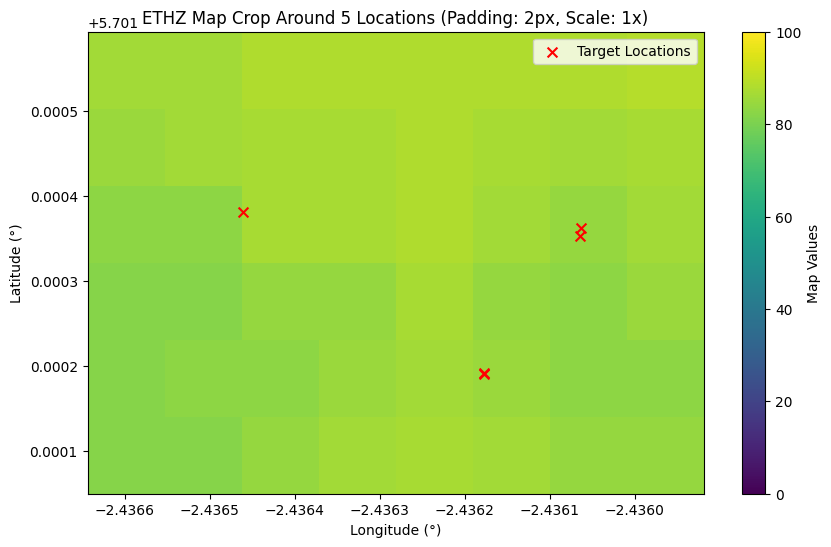

SE02


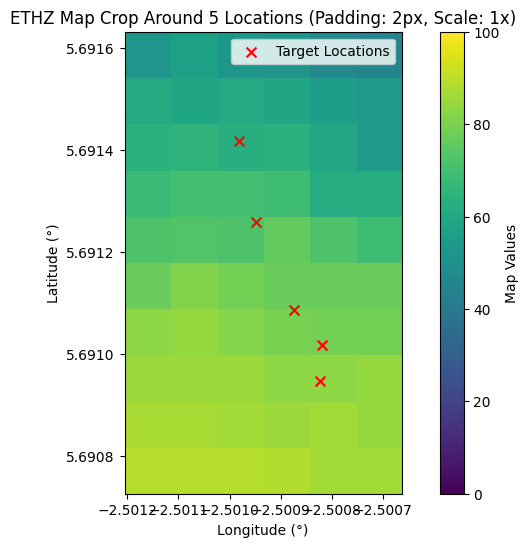

SE03


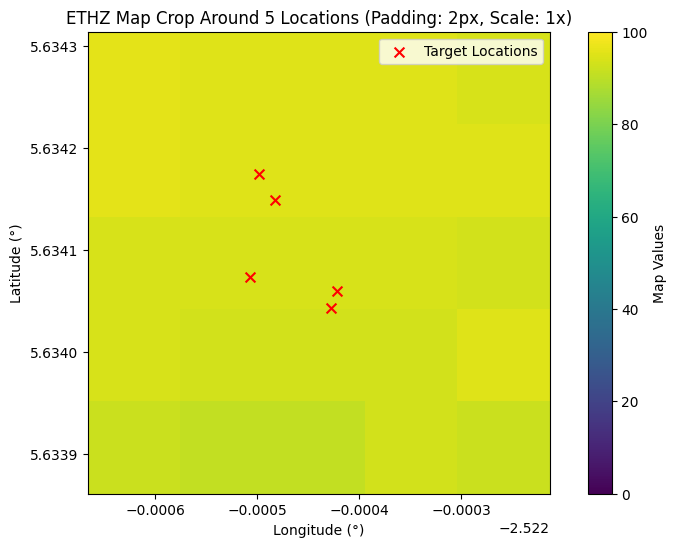

SE04


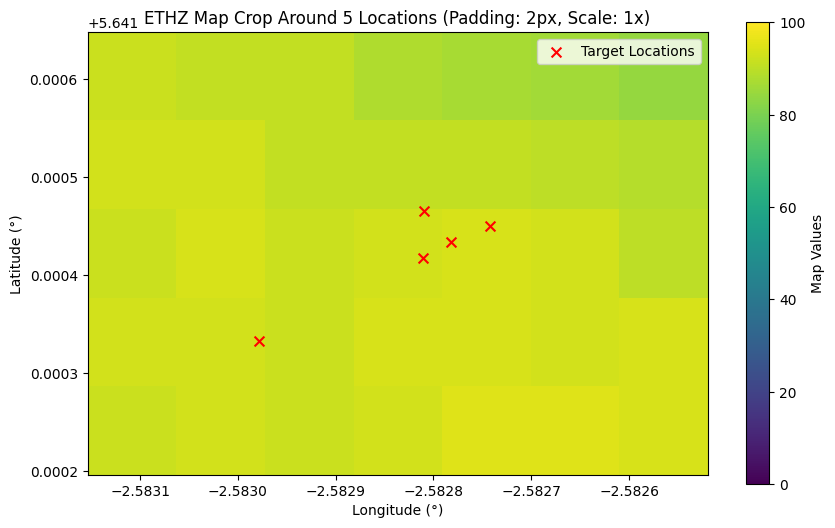

SE05


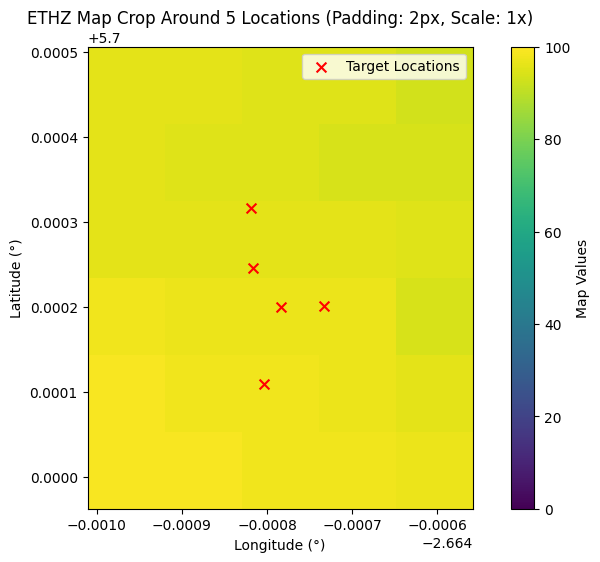

SE06


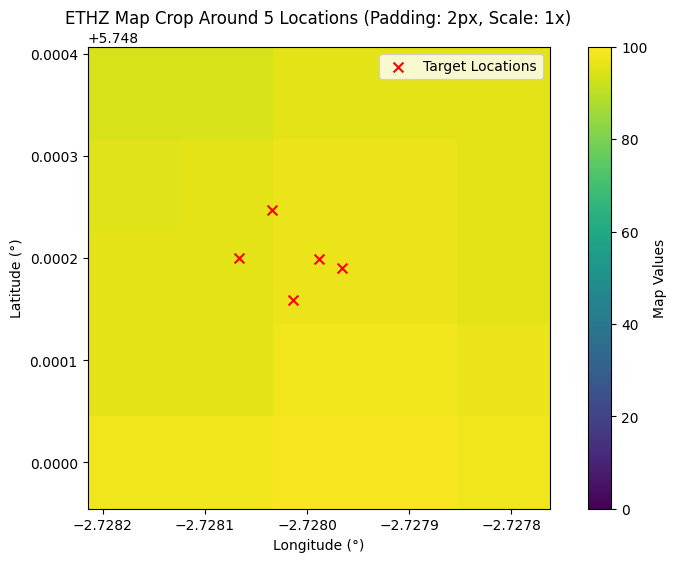

SE07


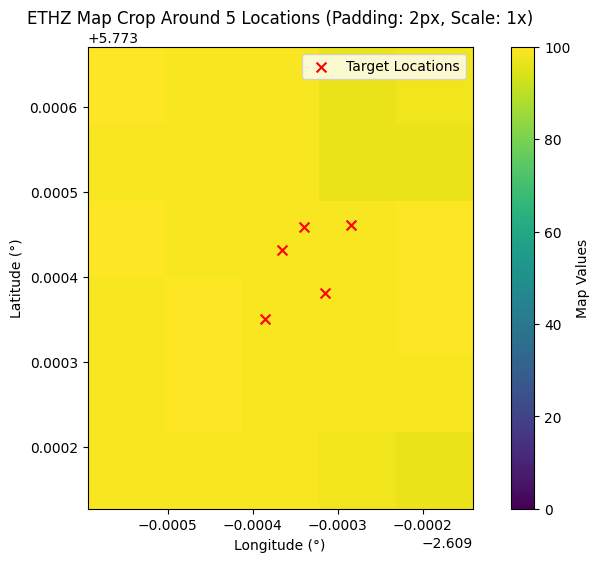

SE08


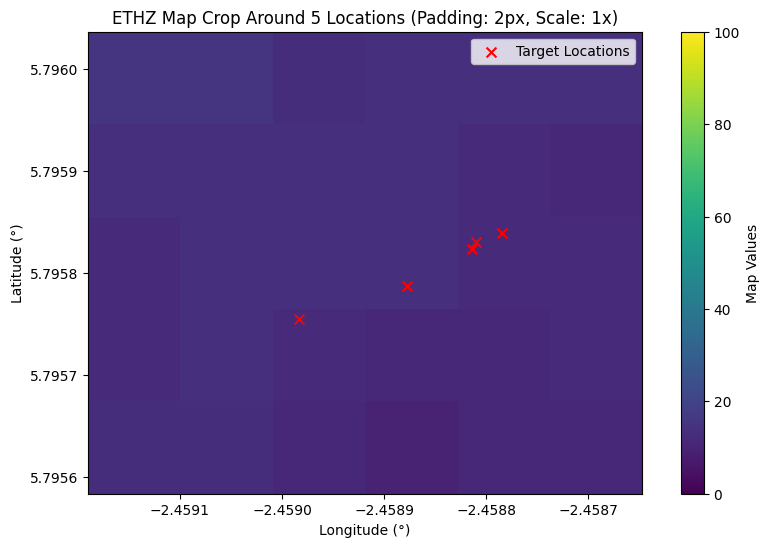

SU01


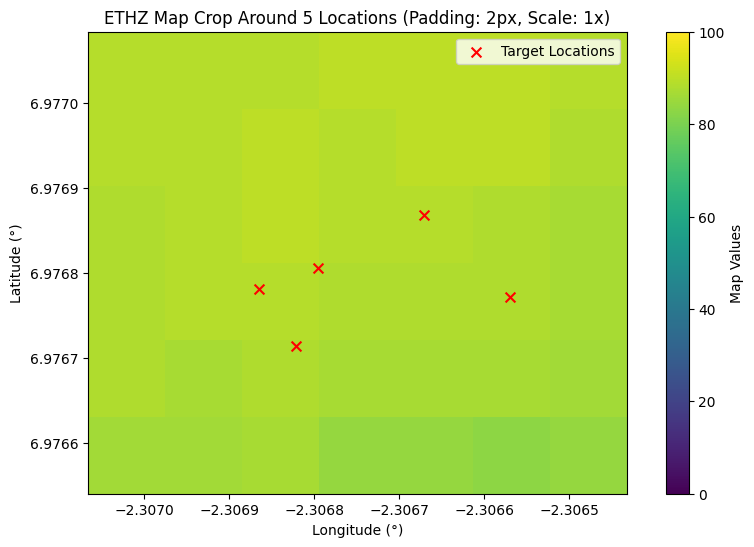

SU02


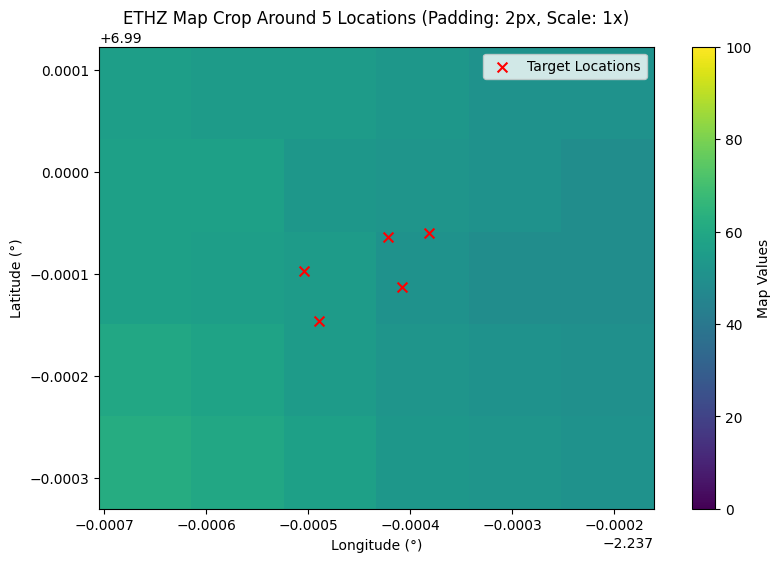

SU03


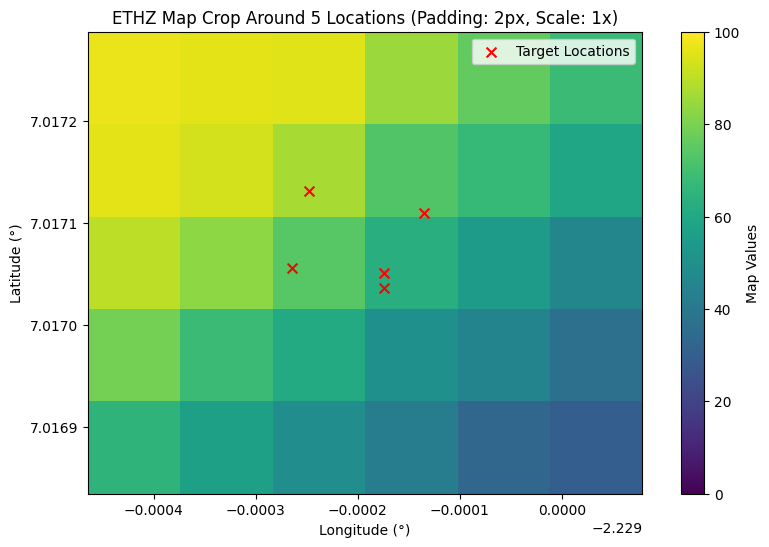

SU04


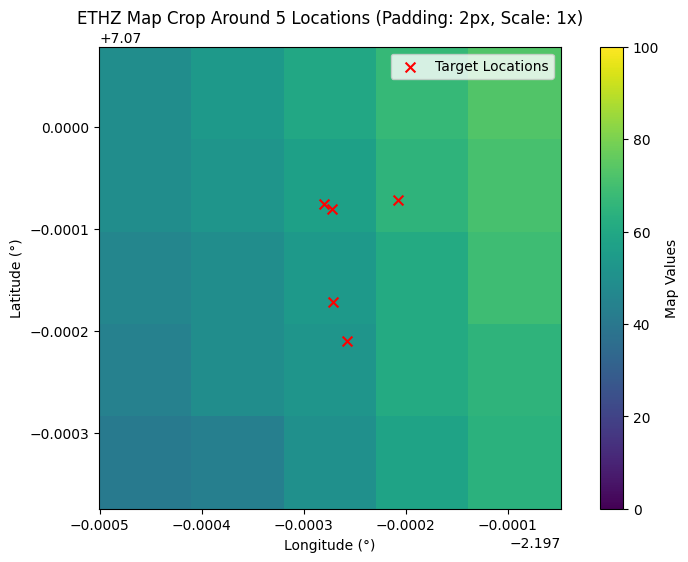

SU05


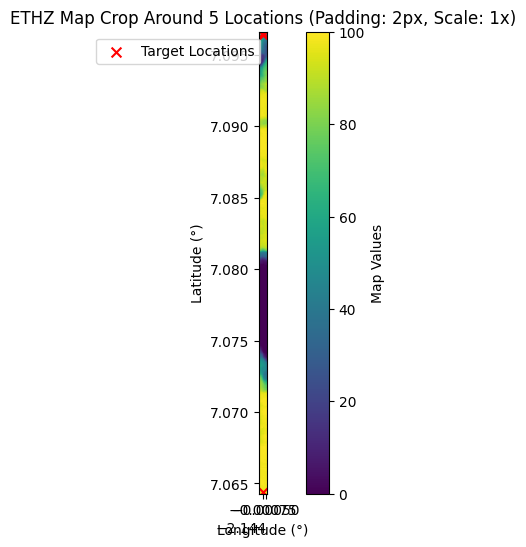

SU06


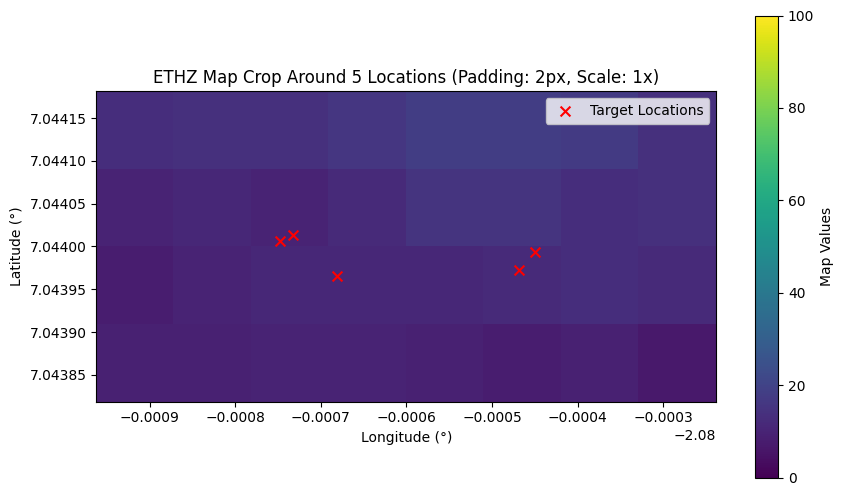

SW01


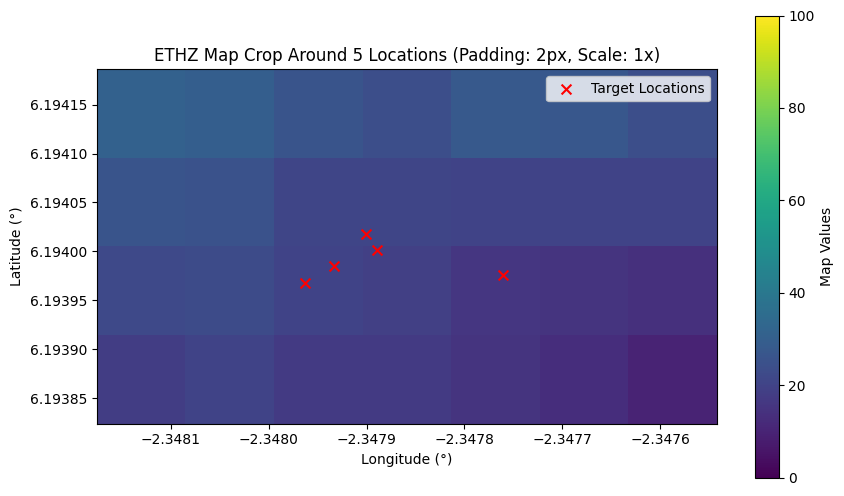

SW02


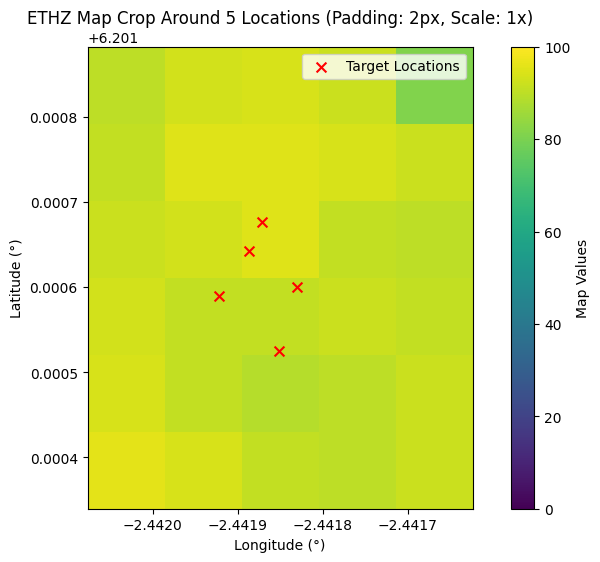

SW03


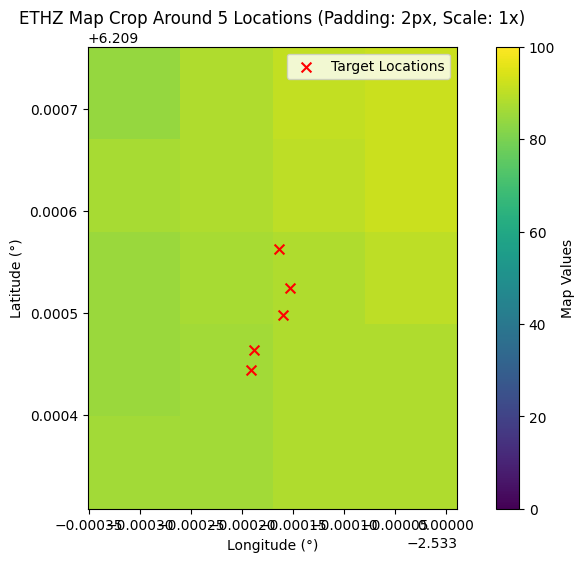

SW04


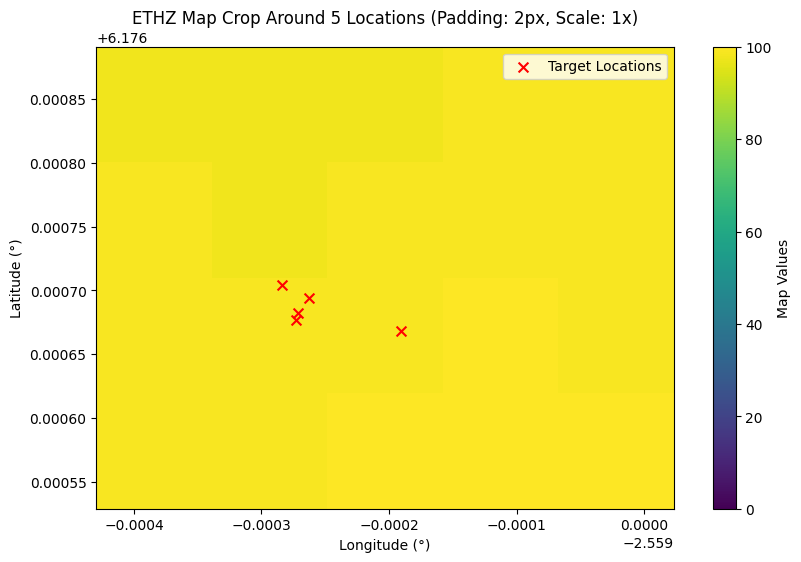

SW05


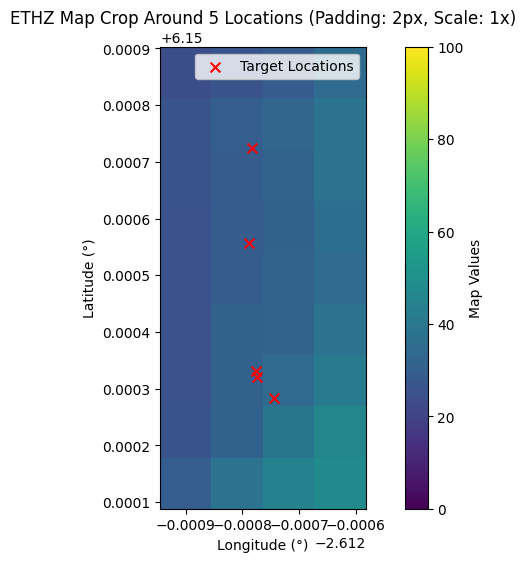

SW06


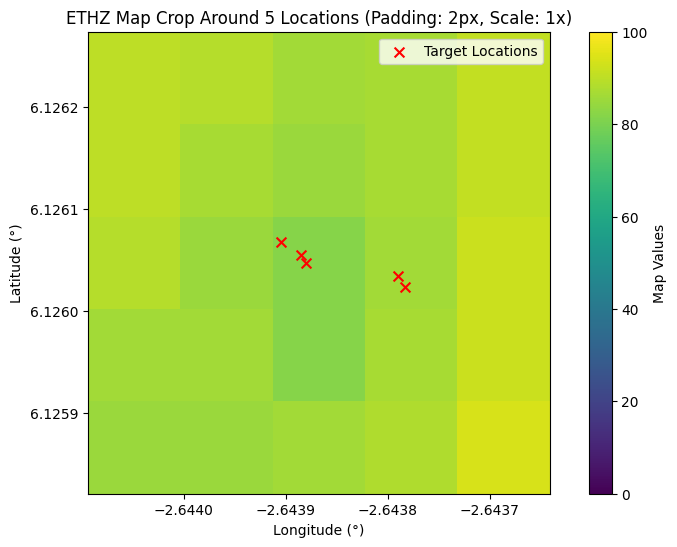

SW07


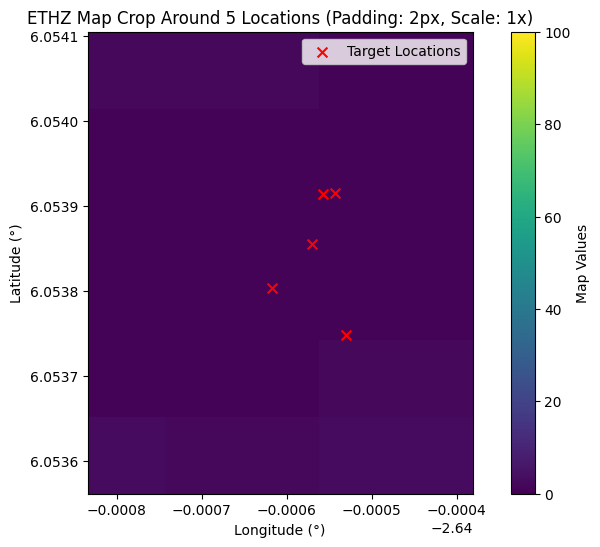

SW10


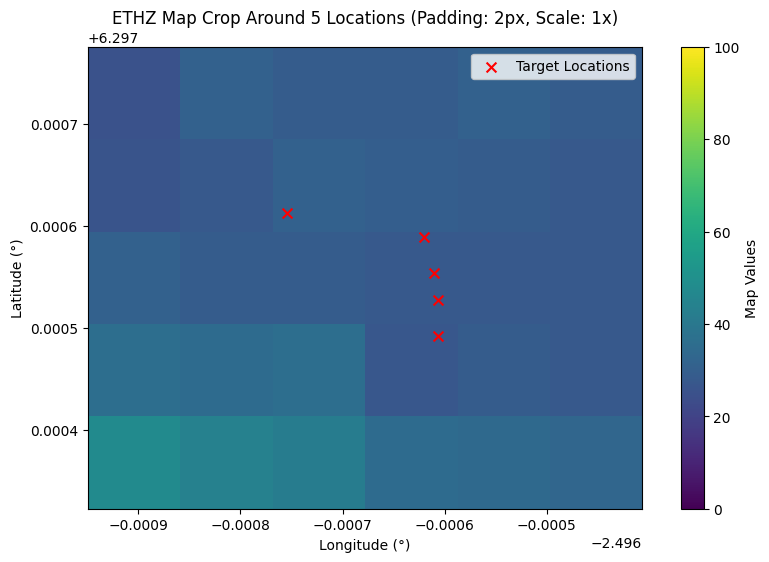

SW11


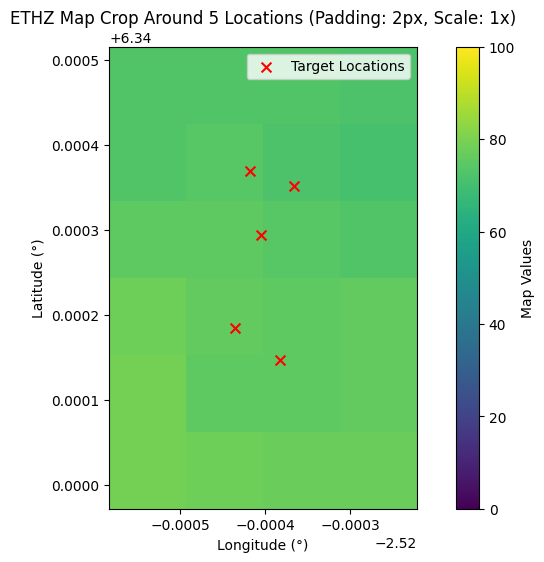

SW12


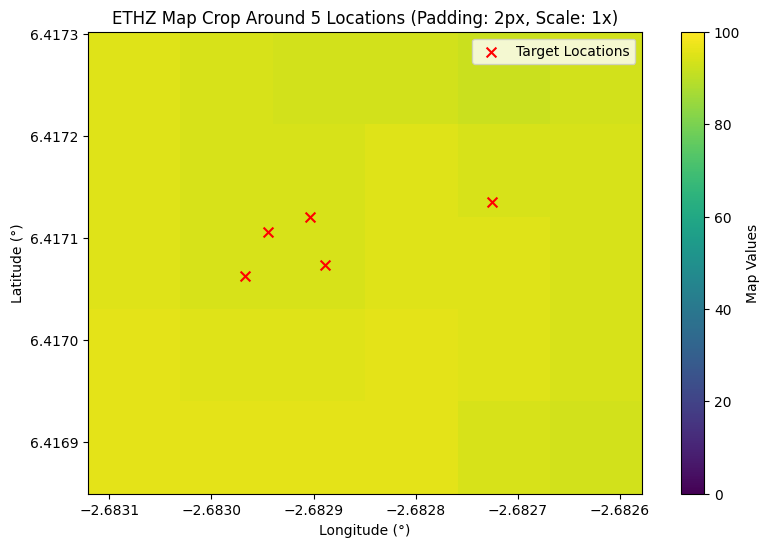

SW13


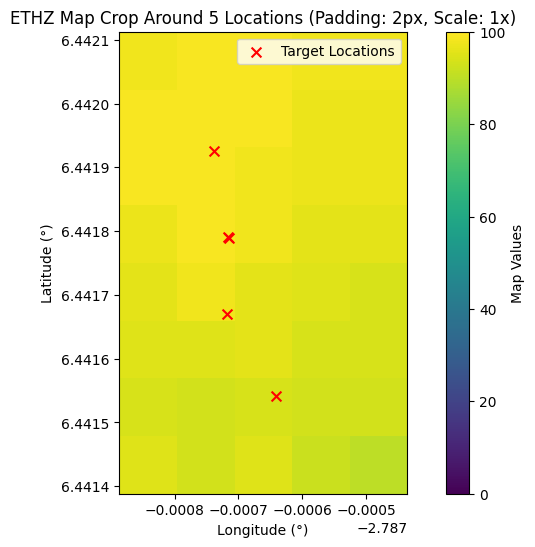

TP01


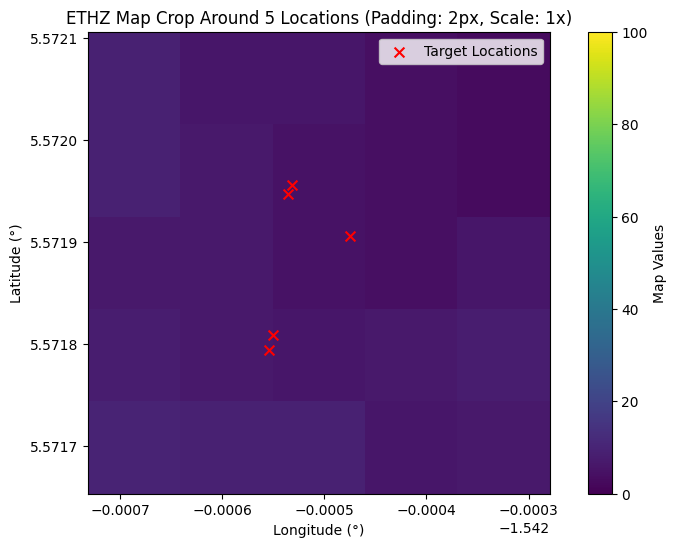

TP02


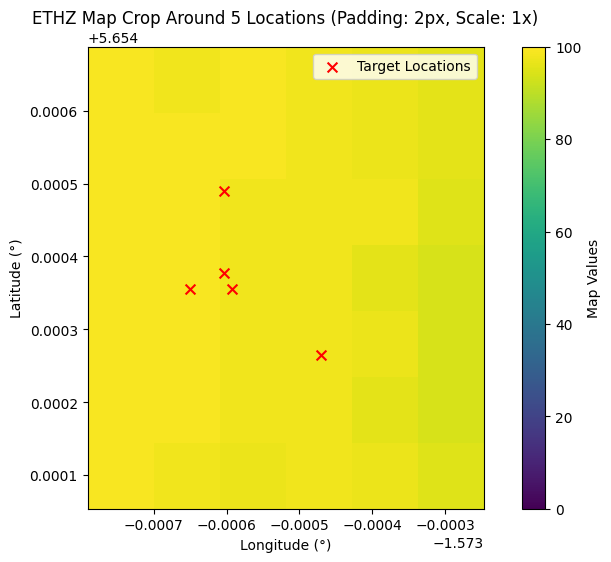

TP03


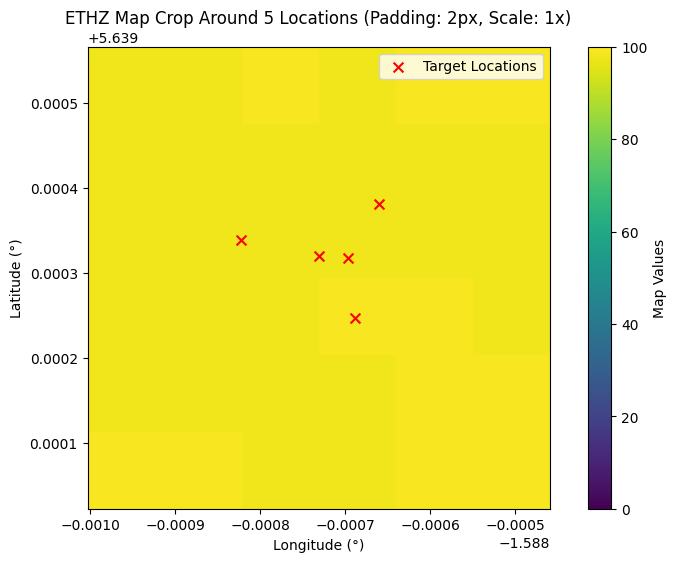

TP04


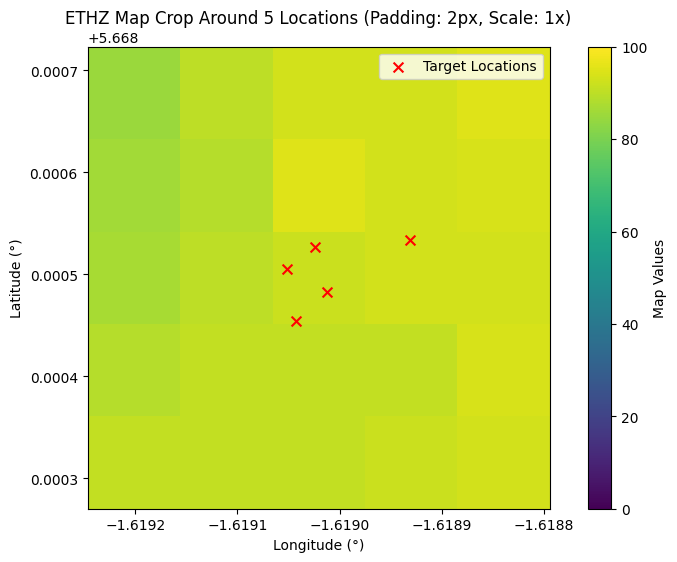

TP05


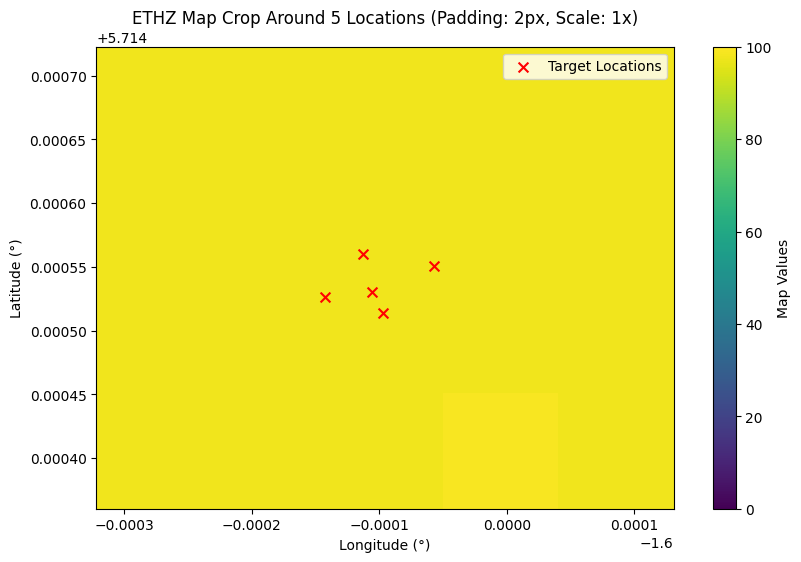

TP06


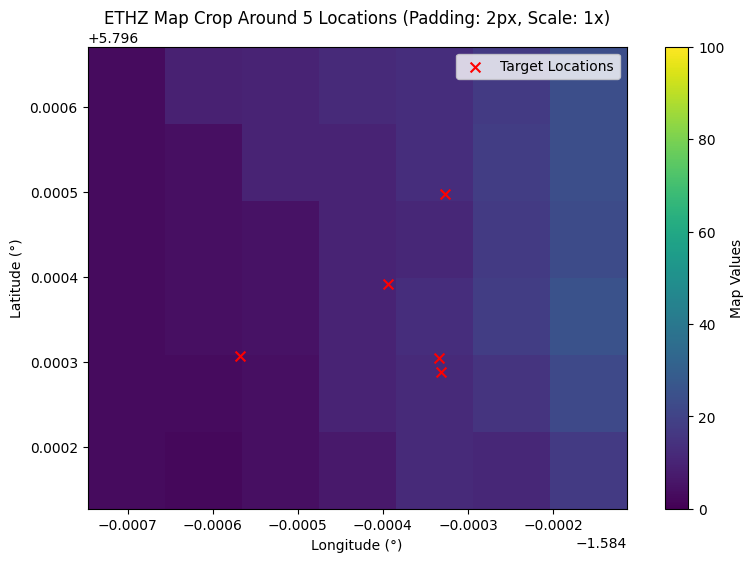

TP07


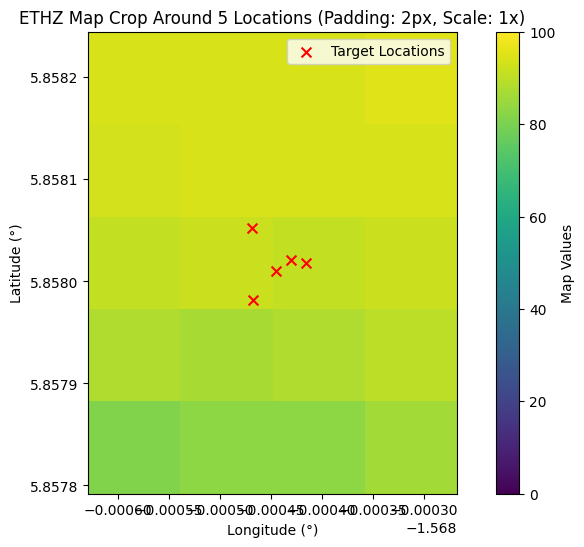

TP08


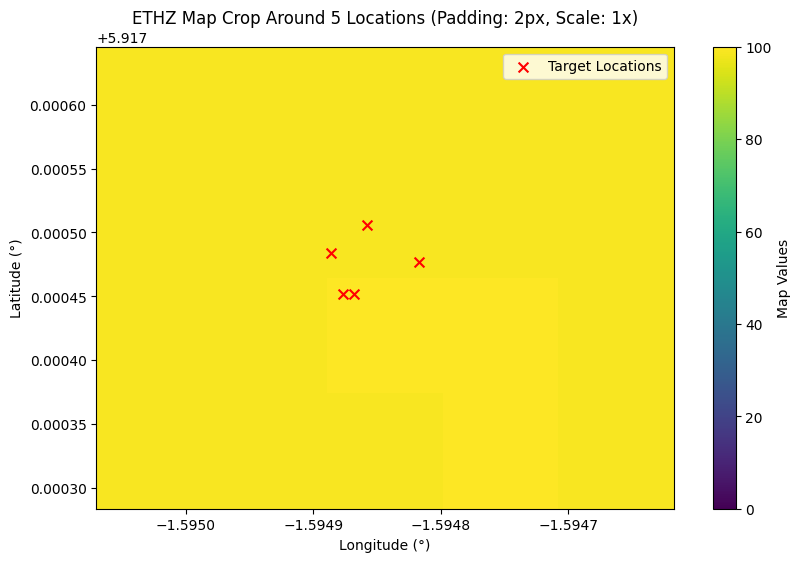

TP09


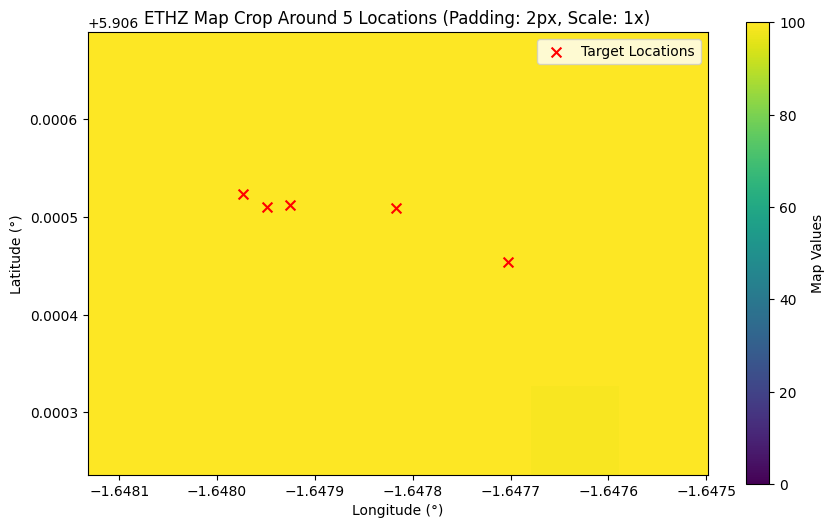

TP10


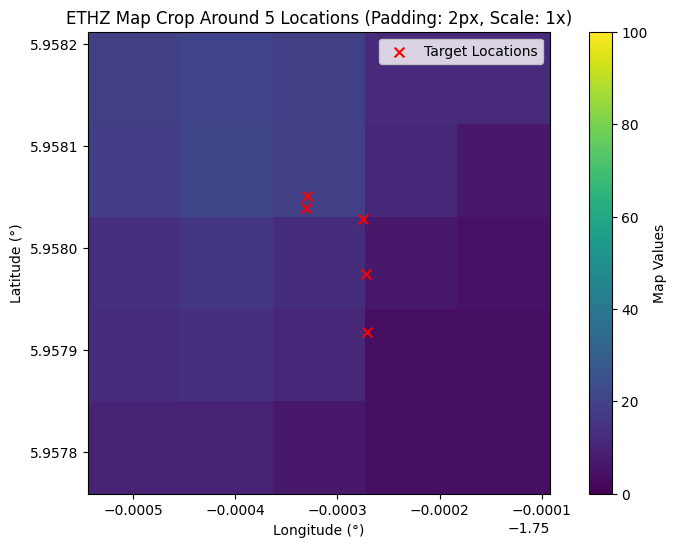

In [57]:
for s in sites:
    print(s.name)
    ethz_map.plot_around_lat_lons(s.lat_lons, padding_px=2, scale_factor=1)

In [69]:
vals = []
for s in sites:
    vals = vals.append(max(ethz_map.get_values(s.lat_lons)))

In [70]:
sns.histplot(vals)

TypeError: object of type 'int' has no len()